In [144]:
!pip install numpy seaborn matplotlib pandas scikit-learn xgboost pycountry statsmodels


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
!pip install catboost shap


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# TFM - Predictive analysis of suicide rates based on socioeconomic determinants and mental health prevalence

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import pycountry
import requests
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Scikit-learn
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
# Regression metrics — will be used in modelling section
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuration
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline
np.random.seed(42)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Preparing the base database
Mental illnesses prevalence extracted from Kaggle

In [2]:
# EU countries list since they are the ones of interest in this analysis
EU_countries_iso = [
    "DEU",
    "AUT",
    "BEL",
    "BGR",
    "CYP",
    "HRV",
    "DNK",
    "SVK",
    "SVN",
    "ESP",
    "EST",
    "FIN",
    "FRA",
    "GRC",
    "HUN",
    "IRL",
    "ITA",
    "LVA",
    "LTU",
    "LUX",
    "MLT",
    "NLD",
    "POL",
    "PRT",
    "CZE",
    "ROU",
    "SWE",
]

# Mapping dictionary based on the ISO alpha-3 codes for the EU
EU_regions = {
    "DEU": "Western Europe/Nordics",
    "FRA": "Western Europe/Nordics",
    "NLD": "Western Europe/Nordics",
    "BEL": "Western Europe/Nordics",
    "LUX": "Western Europe/Nordics",
    "AUT": "Western Europe/Nordics",
    "DNK": "Western Europe/Nordics",
    "FIN": "Western Europe/Nordics",
    "SWE": "Western Europe/Nordics",
    "IRL": "Western Europe/Nordics",
    "ESP": "Mediterranean",
    "ITA": "Mediterranean",
    "PRT": "Mediterranean",
    "GRC": "Mediterranean",
    "CYP": "Mediterranean",
    "MLT": "Mediterranean",
    "POL": "Eastern Europe",
    "CZE": "Eastern Europe",
    "SVK": "Eastern Europe",
    "HUN": "Eastern Europe",
    "ROU": "Eastern Europe",
    "BGR": "Eastern Europe",
    "SVN": "Eastern Europe",
    "HRV": "Eastern Europe",
    "EST": "Baltics",
    "LVA": "Baltics",
    "LTU": "Baltics",
}

social_economic_features = [
    "Suicide rate",  # Objective variable
    "GDP per capita",
    "Unemployment rate (%)",
    "Health expenditure (% GDP)",
    "Population",
    "Urban population (%)",
    "Physicians per 100000",
    "Gini index",
    "Internet users (% of population)",
]

health_related_features = [
    "Suicide rate",  # Objective variable
    "Alcohol use disorders",
    "Alzheimer's disease and other dementias",
    "Anxiety disorders",
    "Attention-deficit/hyperactivity disorder",
    "Autism spectrum disorders",
    "Bipolar disorder",
    "Conduct disorder",
    "Depressive disorders",
    "Schizophrenia",
    "Drug use disorders",
    # Eating disorders excluded — high VIF (12.3), dropped before modelling
]


ID_COLS = ["Country", "Code", "Year", "Region"]
TARGET = "Suicide rate"


# Function to obtain the ISO-Alpha 3 code of the country
def country_code(geo_name):
    """
    Looks up the ISO-Alpha 3 country code based on a given country text name.

    Parameters:
    -----------
    geo_name : str
        The textual name of the country (e.g., "Austria", "Greece").

    Returns:
    --------
    str or None
        The 3-letter ISO code if found (e.g., "AUT"), otherwise None.
    """
    try:
        pais = pycountry.countries.lookup(geo_name)
        return pais.alpha_3
    except LookupError:
        return None


# Function to graph the evolution of a suicide rate per country
def suicide_evolution_graph(dataframe, country_code, country_name):
    """
    Generates and displays a line plot showing the chronological evolution
    of the suicide rate for a specific country.

    Parameters:
    -----------
    dataframe : pd.DataFrame
        The consolidated master dataframe containing 'Code', 'Year', and 'Suicide rate'.
    country_code : str
        The 3-letter ISO code of the target country (e.g., "GRC").
    country_name : str
        The common name of the country to display in the plot title (e.g., "Greece").

    Returns:
    --------
    None
        Renders a matplotlib plot.
    """
    # Filtering dataframe for a specific country code
    df_country = dataframe[dataframe["Code"] == country_code].sort_values("Year")

    # Creating the figure and sizing it
    plt.figure(figsize=(12, 6))

    # Plotting the line with the values for the specified country
    plt.plot(
        df_country["Year"],
        df_country["Suicide rate"],
        color="#1f77b4",
        linestyle="-",
        marker="o",
        linewidth=2.5,
    )

    # Beauty personalization
    plt.title(
        f"Suicide rate evolution in {country_name}",
        fontsize=16,
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Rate per 100,000 inhabitants", fontsize=12)

    # Showing every two years values in X axis
    min_year, max_year = int(df_country["Year"].min()), int(df_country["Year"].max())
    plt.xticks(range(min_year, max_year + 1, 2))

    # Adjusting margins and showing the graph
    plt.tight_layout()
    plt.show()

In [82]:
import os

print(os.getcwd())

d:\TFM\Scripts


In [83]:
# ==============================================================================
# DATA PIPELINE STEP 1: IHME Mental Health Prevalence Base
# Database was filtered on gathering the data to only have EU countries
# ==============================================================================

# Base data from IHME
base_data = pd.read_csv("../data/IHME-GBD_2023_DATA-b62eec84-1.csv")
base_data["Code"] = base_data["location_name"].apply(country_code)
base_data_short = base_data[["location_name", "Code", "year", "cause_name", "val"]]
base_data_pivot = base_data_short.pivot(
    index=["location_name", "Code", "year"], columns="cause_name", values="val"
)
base_data_pivot.columns.name = None
base_data_pivot = base_data_pivot.reset_index()
df_base = base_data_pivot.rename(columns={"location_name": "Country", "year": "Year"})
df_base = df_base.drop(columns=["All causes"])
df = df_base[df_base["Year"] >= 2000].copy()
df

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia
6,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068
7,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193
8,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835
9,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007
10,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236
806,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357
807,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568
808,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098


## World Bank socioeconomic indicators
Indicators chosen:
- GDP per capita (USD). 
- Unemployment rate.
- Health expenditure per country (percentage of GDP).
- Population per country.
- Gini index. Measures the income inequalities. A greater unequality correlates to a greater psychosocial stress.
- Urban population (%). Allows to analyse if the urban environment (isolation, low resources) affects the rate.
- Physicians per 100,000 inhabitants. Measures the health system capability. The lower the rate, the lower the access to psychiatrists.
- Digital connectivity. Internet access could either be an issue for mental health or a network for support.

In [84]:
# ==============================================================================
# DATA PIPELINE STEP 2: Enhanced World Bank API Extraction
# ==============================================================================

# Defining the parameters in the URL of the API v2
INDICATORS = {
    "NY.GDP.PCAP.CD": "GDP per capita",
    "SL.UEM.TOTL.ZS": "Unemployment rate (%)",
    "SH.XPD.CHEX.GD.ZS": "Health expenditure (% GDP)",
    "SP.POP.TOTL": "Population",
    "SI.POV.GINI": "Gini index",
    "SP.URB.TOTL.IN.ZS": "Urban population (%)",
    "SH.MED.PHYS.ZS": "Physicians per 1000",
    "IT.NET.USER.ZS": "Internet users (% of population)",
}
REGION = "ALL"

df_features = df.copy()

for code, column_name in INDICATORS.items():
    url_wb = f"http://api.worldbank.org/v2/country/{REGION}/indicator/{code}?format=json&per_page=10000&date=2000:2026"

    # SSL certificate verification disabled for local network compatibility.
    # Remove verify=False if running in a production or public environment.
    response = requests.get(url_wb, verify=False)

    if response.status_code == 200:
        # World Bank returns a list where [0] is paging and [1] is the actual data
        raw_data = response.json()[1]

        # Converting to DataFrame
        df_wb = pd.DataFrame(raw_data)

        # It is a nested JSON, where country is a dictionary, which needs to be flattened:
        df_wb["Country"] = df_wb["country"].apply(lambda x: x["value"])
        df_wb["Code"] = df_wb["countryiso3code"].str.upper()
        df_wb["Year"] = df_wb["date"].astype(int)
        df_wb[column_name] = df_wb["value"]

        # Cleaning and ordering
        df_final_wb = df_wb[["Country", "Code", "Year", column_name]].dropna()

        df_final_eu = df_final_wb[df_final_wb["Code"].isin(EU_countries_iso)].copy()

        df_features = pd.merge(
            df_features,
            df_final_eu[["Code", "Year", column_name]],
            on=["Code", "Year"],
            how="left",
        )

        print(
            f"DataFrame '{column_name}' successfully created. Rows retrieved: {len(df_final_eu)}."
        )
        print("-" * 50)

if "Physicians per 1000" in df_features.columns:
    df_features["Physicians per 100000"] = df_features["Physicians per 1000"] * 100
    df_features.drop(columns=["Physicians per 1000"], inplace=True)

df_features

DataFrame 'GDP per capita' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Unemployment rate (%)' successfully created. Rows retrieved: 702.
--------------------------------------------------
DataFrame 'Health expenditure (% GDP)' successfully created. Rows retrieved: 663.
--------------------------------------------------
DataFrame 'Population' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Gini index' successfully created. Rows retrieved: 589.
--------------------------------------------------
DataFrame 'Urban population (%)' successfully created. Rows retrieved: 675.
--------------------------------------------------
DataFrame 'Physicians per 1000' successfully created. Rows retrieved: 616.
--------------------------------------------------
DataFrame 'Internet users (% of population)' successfully created. Rows retrieved: 678.
-------------------------------------------

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Sweden,SWE,2019,2897.498890,1355.018452,4681.325510,837.347190,1009.227065,691.369692,389.980052,4071.965808,930.633756,462.785702,285.952236,51648.989282,6.833,10.934443,10278887.0,29.3,87.708842,94.493443,428.8
644,Sweden,SWE,2020,2776.695254,1371.340819,5729.796753,838.083163,1009.305732,690.913455,393.404674,4978.454347,934.750734,463.972841,285.502357,52568.572698,8.291,11.424587,10353442.0,28.9,87.942405,94.539431,432.2
645,Sweden,SWE,2021,2731.449349,1377.436844,5774.235422,839.038586,1009.554676,687.203737,396.199380,4601.316049,938.469081,467.280088,285.717568,60647.541637,8.803,11.230136,10415811.0,29.8,88.174165,94.670316,440.8
646,Sweden,SWE,2022,2709.865933,1410.557957,6240.680967,838.776139,1008.378063,683.488721,397.687661,4888.626199,941.071338,469.844997,285.905098,54836.890724,7.417,10.855057,10486941.0,31.6,88.403858,95.009703,NaN


## Preparing the WHO database for the join with the master database (predictive variable: suicide rate)

In [85]:
# ==============================================================================
# DATA PIPELINE STEP 3: WHO API Suicide Rates Join
# ==============================================================================

# Official indicator from the WHO for the mortality rate due to self-harm
INDICATOR = "SDGSUICIDE"
url = f"https://ghoapi.azureedge.net/api/{INDICATOR}"

print("Downloading dataset from the WHO API.")
response = requests.get(url, verify=False)

if response.status_code == 200:
    data = response.json()["value"]

    # Testing if the response returned any value.
    if len(data) == 0:
        print("The API responded but did not find any data for this indicator.")
    else:
        df_raw = pd.DataFrame(data)

        # Filtering to only keep BTSX (both sexes) and YEARSALL (all year groups).
        df_filtered = df_raw[
            (df_raw["Dim1"] == "SEX_BTSX") & (df_raw["Dim2"] == "AGEGROUP_YEARSALL")
        ].copy()

        # Selecting the columns of interest
        interest_columns = ["SpatialDim", "TimeDim", "NumericValue"]
        df_clean = df_filtered[interest_columns].copy()

        # Renaming to match the rest of the datasets
        df_clean.columns = ["Code", "Year", "Suicide rate"]

        # Sort chronologically by country and year
        df_clean = df_clean.sort_values(by=["Code", "Year"])

else:
    print(f"Error trying to connect with the API. Status code: {response.status_code}")

df_complete = pd.merge(
    df_features,
    df_clean[["Code", "Year", "Suicide rate"]],
    on=["Code", "Year"],
    how="left",
)

# Sort by country and year to ensure correct chronological ordering
# before interpolation and downstream groupby operations
df_complete = df_complete.sort_values(by=["Country", "Year"]).reset_index(drop=True)

# Separate the data set between the real world (not-known suicide rates) and the rest of the data
df_development = df_complete[df_complete["Year"] <= 2021].copy()
# Retain df_real_world for reference only — WHO data for 2022-2023 is unavailable
# so this dataset has no suicide rate labels and is not used in modelling.
df_real_world = df_complete[df_complete["Year"] >= 2022].copy()

display(df_development.head())

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.0,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,NaN,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,NaN,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.5,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.8,66.955861,54.280000,423.2,17.383069


In [86]:
# ==============================================================================
# 1. DESCRIPTIVE STATISTICS
# ==============================================================================
print("Master Dataset Summary Statistics")
display(df_development.describe().T)

print("\nMissing values")
print(df_development.isnull().sum())

Master Dataset Summary Statistics


,count,mean,std,min,25%,50%,75%,max
Year,594.0,2.010500e+03,6.349636e+00,2000.000000,2.005000e+03,2.010500e+03,2.016000e+03,2.021000e+03
Alcohol use disorders,594.0,2.640863e+03,6.501545e+02,1468.353858,2.154470e+03,2.638039e+03,3.166213e+03,3.930876e+03
Alzheimer's disease and other dementias,594.0,1.162906e+03,3.505339e+02,615.594485,9.072604e+02,1.109865e+03,1.317172e+03,2.490327e+03
Anxiety disorders,594.0,5.060044e+03,1.514067e+03,2850.328655,3.934236e+03,4.670571e+03,5.770123e+03,1.142191e+04
Attention-deficit/hyperactivity disorder,594.0,7.675910e+02,3.598561e+02,248.480691,4.405874e+02,7.954818e+02,9.792250e+02,1.722195e+03
Autism spectrum disorders,594.0,6.979302e+02,1.188224e+02,497.467873,5.765145e+02,7.303758e+02,7.675203e+02,1.011089e+03
Bipolar disorder,594.0,6.507963e+02,8.939936e+01,488.696921,5.619674e+02,6.689073e+02,7.169895e+02,8.472123e+02
Conduct disorder,594.0,3.712084e+02,5.047307e+01,281.621053,3.309906e+02,3.666408e+02,4.003332e+02,5.418604e+02
Depressive disorders,594.0,3.332831e+03,7.327951e+02,2229.578134,2.753071e+03,3.272819e+03,3.777113e+03,6.698489e+03
Drug use disorders,594.0,8.564169e+02,2.555415e+02,282.936650,6.690521e+02,8.318342e+02,9.782403e+02,1.852197e+03



Missing values
Country                                      0
Code                                         0
Year                                         0
Alcohol use disorders                        0
Alzheimer's disease and other dementias      0
Anxiety disorders                            0
Attention-deficit/hyperactivity disorder     0
Autism spectrum disorders                    0
Bipolar disorder                             0
Conduct disorder                             0
Depressive disorders                         0
Drug use disorders                           0
Eating disorders                             0
Schizophrenia                                0
GDP per capita                               0
Unemployment rate (%)                        0
Health expenditure (% GDP)                   0
Population                                   0
Gini index                                  54
Urban population (%)                         0
Internet users (% of population)            

## Inspecting missing values: Gini index and Physicians per 100,000
To have a clear idea of which value imputation method to use

In [87]:
print(
    df_development[
        df_development["Gini index"].isna()
        | df_development["Physicians per 100000"].isna()
    ]
)

         Country Code  Year  Alcohol use disorders  Alzheimer's disease and other dementias  Anxiety disorders  Attention-deficit/hyperactivity disorder  Autism spectrum disorders  Bipolar disorder  Conduct disorder  Depressive disorders  Drug use disorders  Eating disorders  Schizophrenia  GDP per capita  Unemployment rate (%)  Health expenditure (% GDP)  Population  Gini index  Urban population (%)  Internet users (% of population)  Physicians per 100000  Suicide rate
1        Austria  AUT  2001            3193.762279                              1143.969355        4046.938653                               1173.433463                 723.015405        719.736433        394.027233           2414.230764          875.548127        479.489990     342.045193    24430.495983                  4.007                    9.452435   8042293.0         NaN             66.840816                         39.185450                  398.9     18.508048
2        Austria  AUT  2002            3196.670699

## Missing values imputation
Linear interpolation chosen since there are consecutive years missing.

In [88]:
# Define the columns with missing values
features_with_NaN = ["Gini index", "Physicians per 100000"]

for col in features_with_NaN:
    # Linear interpolation within each country (only fills between known points)
    df_development[col] = df_development.groupby("Country")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

print("Remaining NaNs after interpolation:")
print(df_development[features_with_NaN].isnull().sum())

display(df_development.head())
print(df_development.isnull().sum())

Remaining NaNs after interpolation:
Gini index               0
Physicians per 100000    0
dtype: int64


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Eating disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,479.043042,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,479.489990,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,479.784032,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,480.160291,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.700000,414.4,17.989560
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,480.506984,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.280000,423.2,17.383069


Country                                     0
Code                                        0
Year                                        0
Alcohol use disorders                       0
Alzheimer's disease and other dementias     0
Anxiety disorders                           0
Attention-deficit/hyperactivity disorder    0
Autism spectrum disorders                   0
Bipolar disorder                            0
Conduct disorder                            0
Depressive disorders                        0
Drug use disorders                          0
Eating disorders                            0
Schizophrenia                               0
GDP per capita                              0
Unemployment rate (%)                       0
Health expenditure (% GDP)                  0
Population                                  0
Gini index                                  0
Urban population (%)                        0
Internet users (% of population)            0
Physicians per 100000             

## Suicide rate evolution — country spotlights
The following plots highlight the two extremes of the EU distribution and a mid-range reference country, contextualising the outliers identified later.

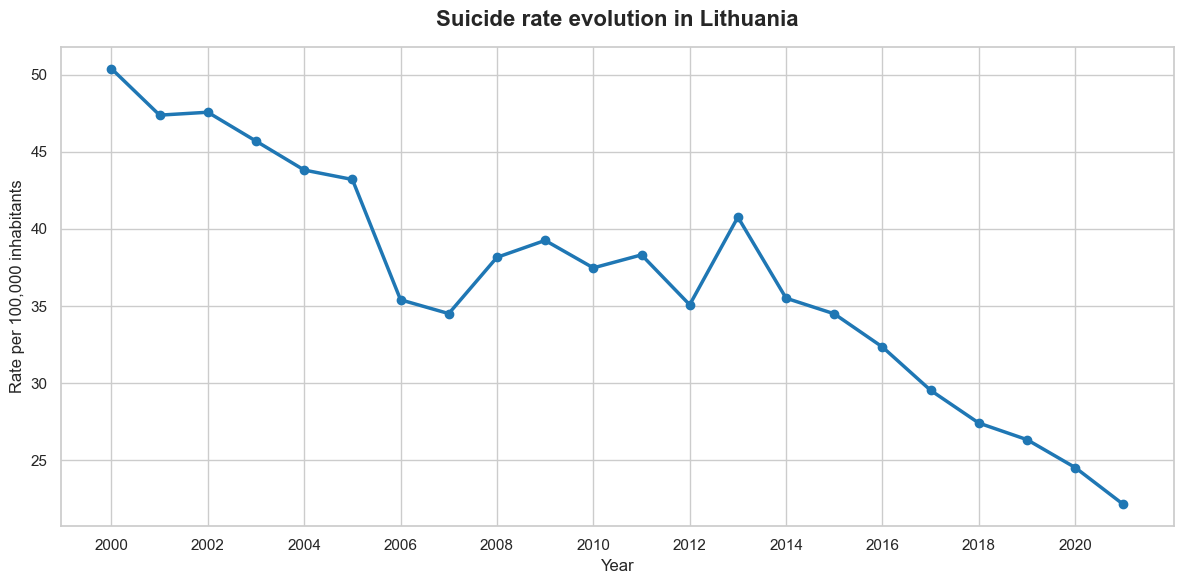

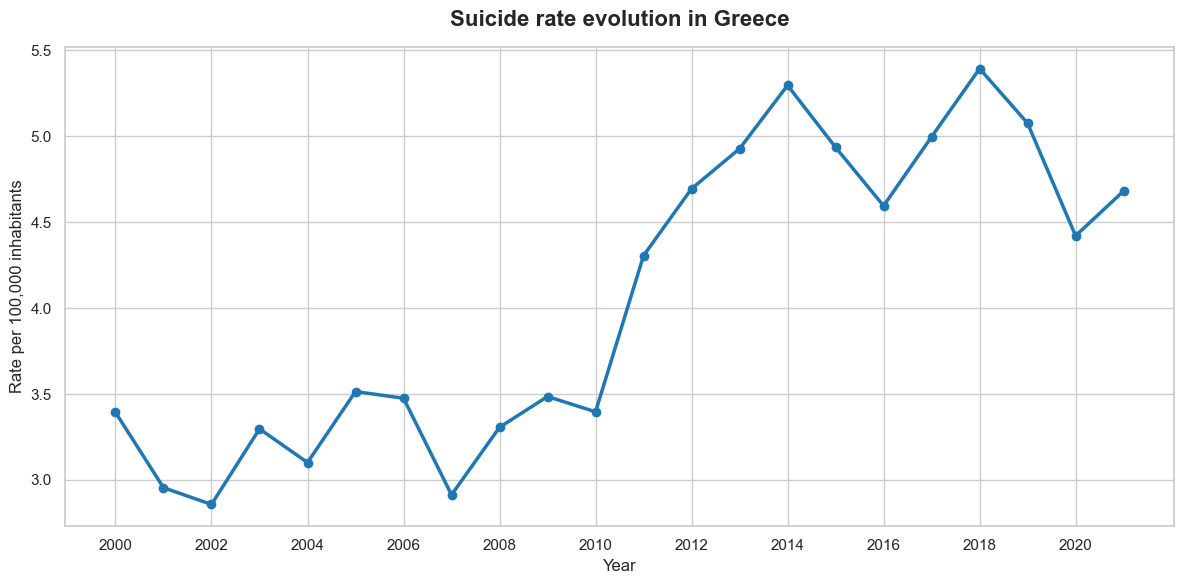

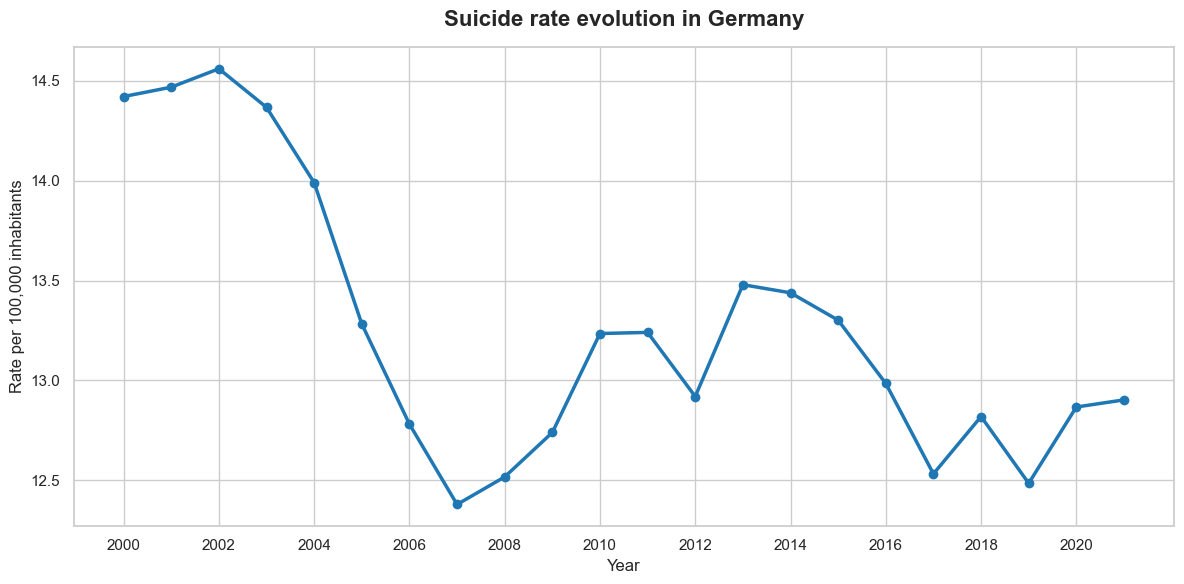

In [89]:
# Highest average suicide rate in the EU
suicide_evolution_graph(df_development, "LTU", "Lithuania")

# Lowest average suicide rate in the EU
suicide_evolution_graph(df_development, "GRC", "Greece")

# A mid-range country for reference
suicide_evolution_graph(df_development, "DEU", "Germany")

## Suicide rate trends by EU region (2000–2021)

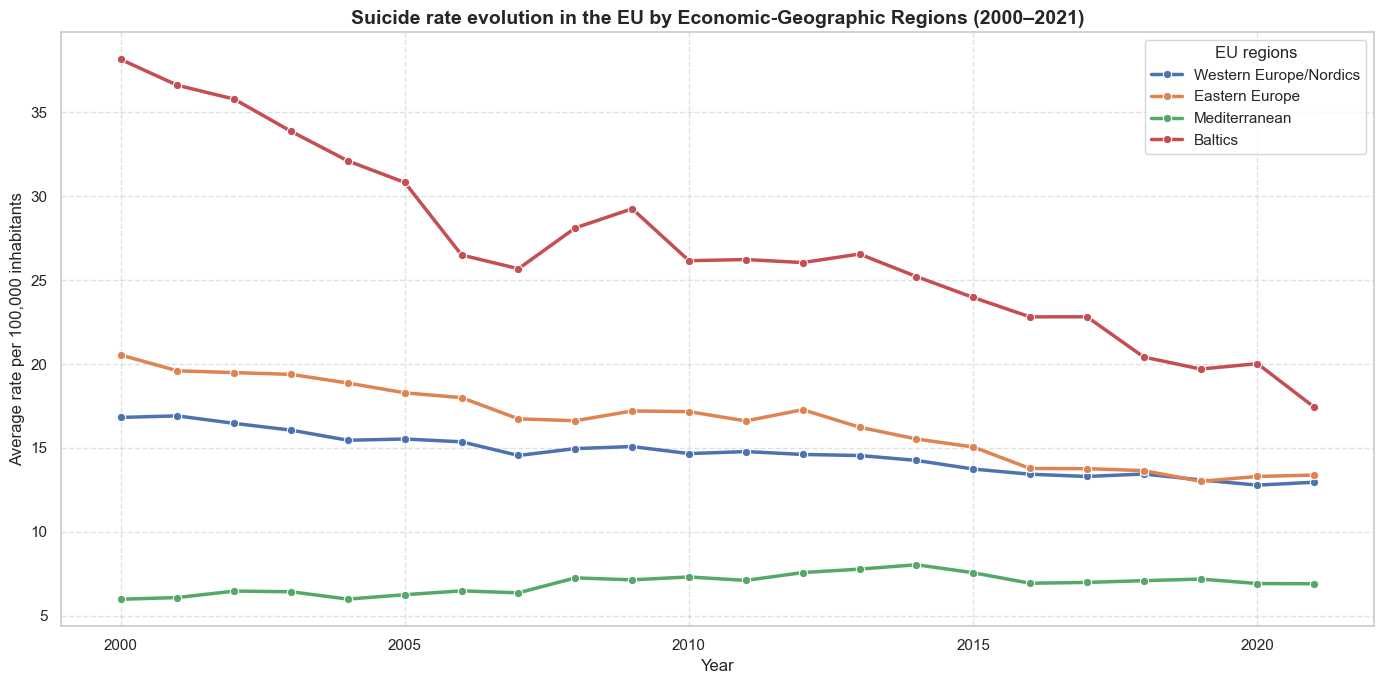

In [90]:
df_development["Region"] = df_development["Code"].map(EU_regions)

# Graphing the time evolution per region
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=df_development,
    x="Year",
    y="Suicide rate",
    hue="Region",
    marker="o",
    linewidth=2.5,
    errorbar=None,
)

plt.title(
    "Suicide rate evolution in the EU by Economic-Geographic Regions (2000–2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Year")
plt.ylabel("Average rate per 100,000 inhabitants")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="EU regions")
plt.tight_layout()
plt.show()

## Cross-country distribution analysis

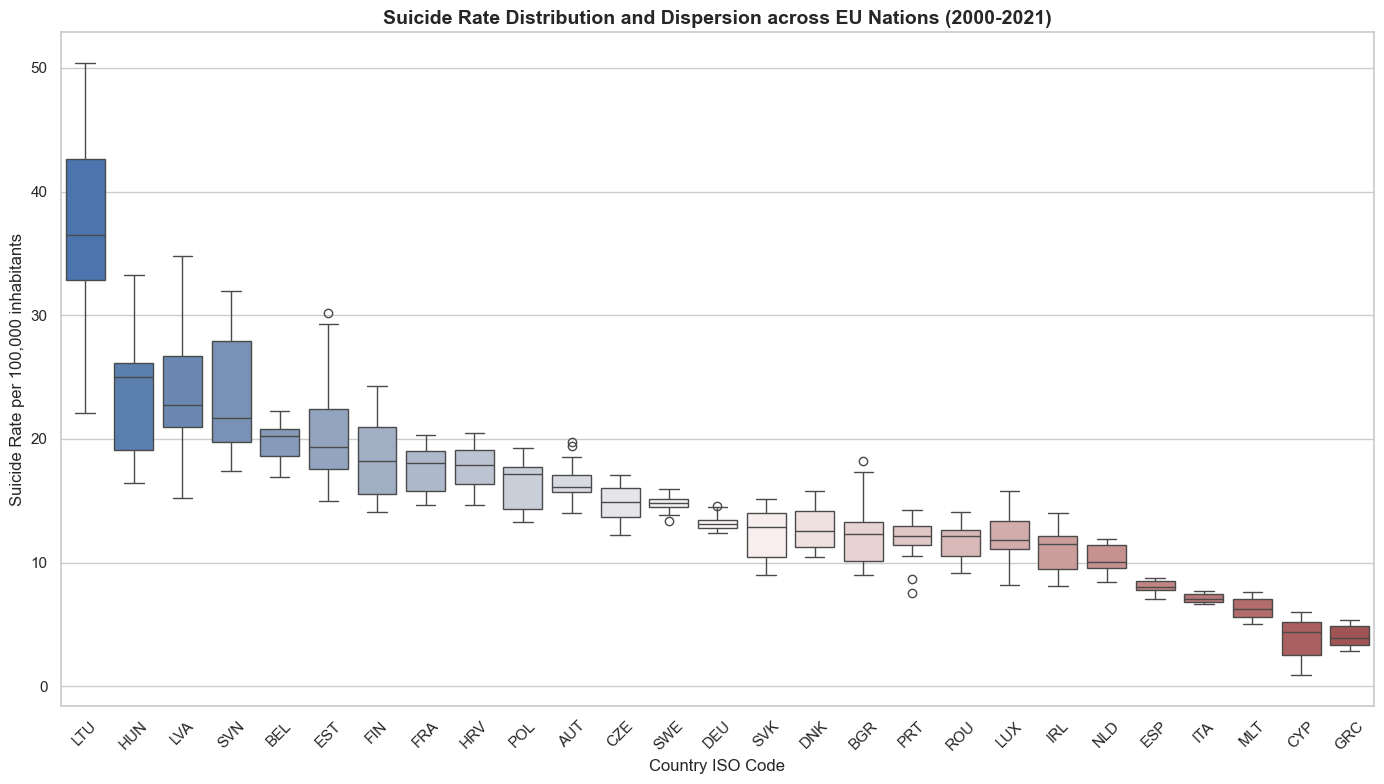

In [91]:
# ==============================================================================
# CROSS-COUNTRY DISTRIBUTION ANALYSIS
# ==============================================================================
# Distribution of Suicide Rates across different EU nations
plt.figure(figsize=(14, 8))
sns.boxplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    palette="vlag",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
)
plt.title(
    "Suicide Rate Distribution and Dispersion across EU Nations (2000-2021)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Country ISO Code")
plt.ylabel("Suicide Rate per 100,000 inhabitants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature distribution analysis

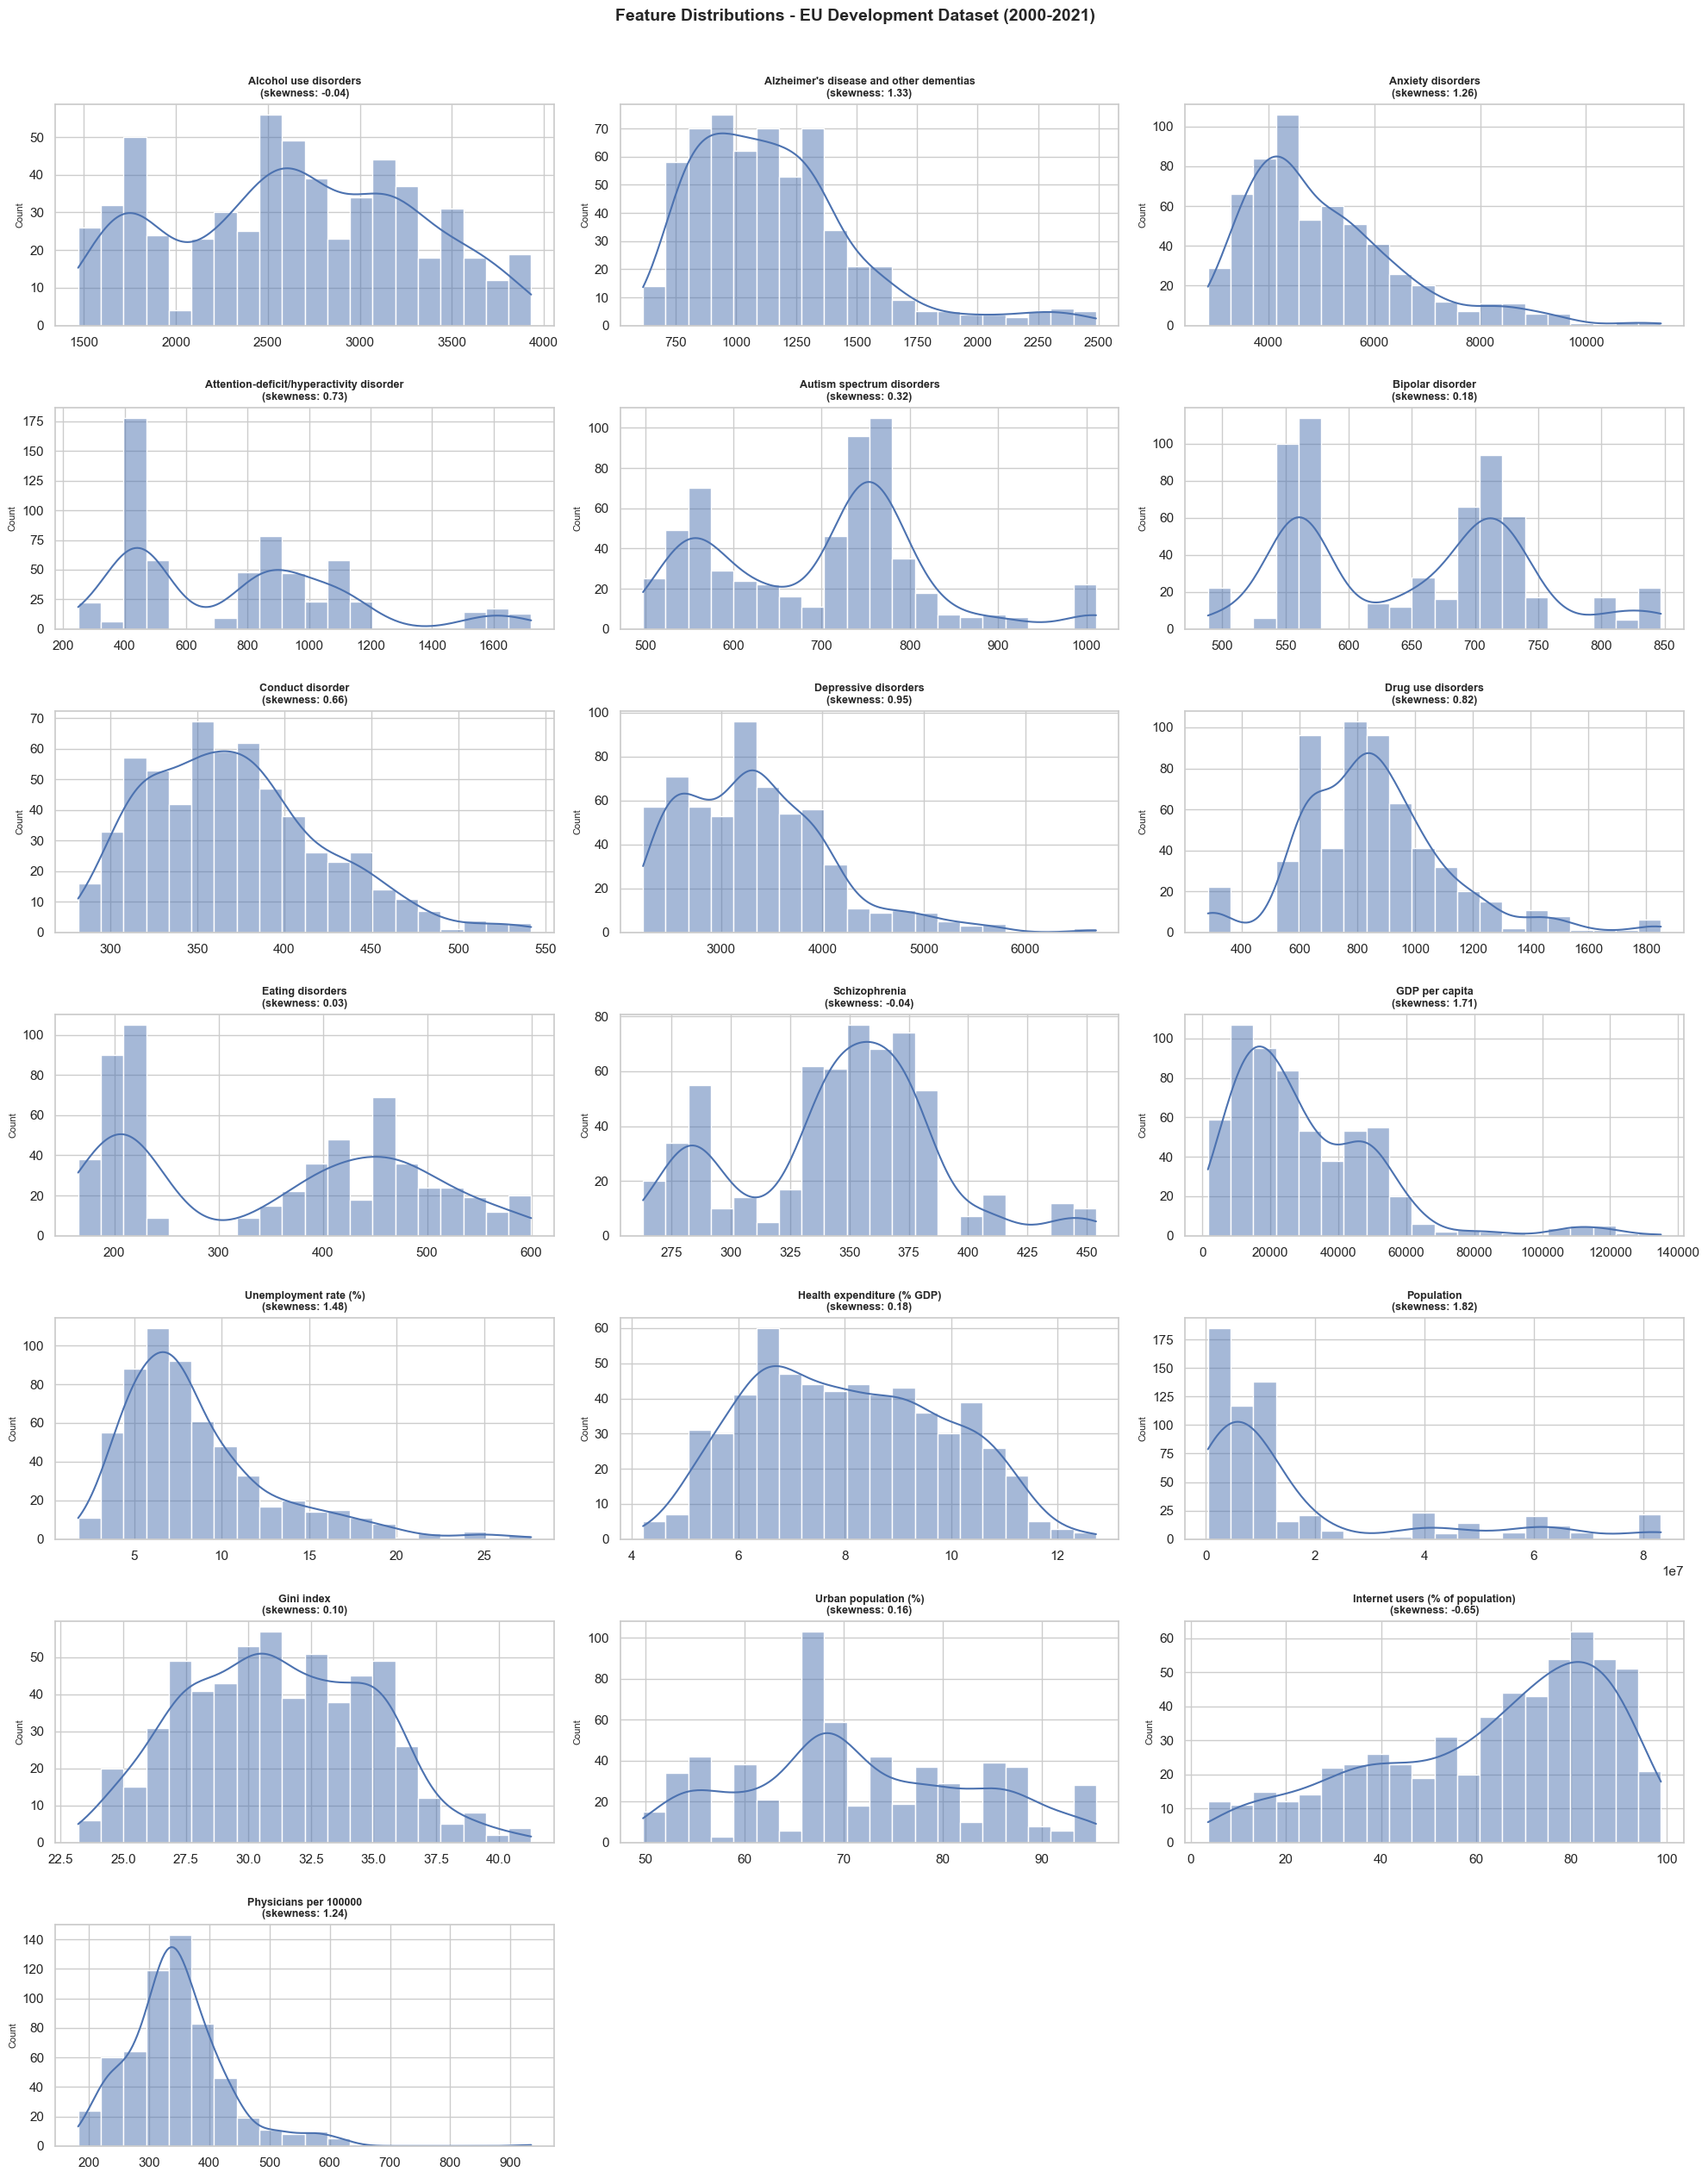


Skewness summary:
Population                                  1.82
GDP per capita                              1.71
Unemployment rate (%)                       1.48
Alzheimer's disease and other dementias     1.33
Anxiety disorders                           1.26
Physicians per 100000                       1.24
Depressive disorders                        0.95
Drug use disorders                          0.82
Attention-deficit/hyperactivity disorder    0.73
Conduct disorder                            0.66
Autism spectrum disorders                   0.32
Health expenditure (% GDP)                  0.18
Bipolar disorder                            0.18
Urban population (%)                        0.16
Gini index                                  0.10
Eating disorders                            0.03
Alcohol use disorders                      -0.04
Schizophrenia                              -0.04
Internet users (% of population)           -0.65
dtype: float64


In [92]:
# ==============================================================================
# FEATURE DISTRIBUTION ANALYSIS
# Histograms + KDE for all numerical features to identify skewness
# ==============================================================================

predictor_features = [c for c in df_development.columns if c not in ID_COLS + [TARGET]]

ncols = 3
nrows = (len(predictor_features) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(predictor_features):
    ax = axes[i]
    data_col = df_development[col].dropna()
    sns.histplot(data_col, kde=True, ax=ax, color="#4C72B0", bins=20)
    skew_val = data_col.skew()
    ax.set_title(f"{col}\n(skewness: {skew_val:.2f})", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count", fontsize=8)

for j in range(len(predictor_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Feature Distributions - EU Development Dataset (2000-2021)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

print("\nSkewness summary:")
print(df_development[predictor_features].skew().sort_values(ascending=False).round(2))

## Outlier detection

Outlier Summary (IQR method, threshold=1.5):


,Feature,Outlier count,Outlier %,Lower bound,Upper bound
4,Population,110,18.52,-16125106.75,35771617.25
2,Unemployment rate (%),31,5.22,-1.35,17.25
6,Physicians per 100000,26,4.38,163.24,517.34
0,Suicide rate,23,3.87,-2.05,30.30
1,GDP per capita,18,3.03,-28443.29,85443.25
3,Health expenditure (% GDP),0,0.00,2.28,13.70
5,Urban population (%),0,0.00,36.69,106.22
7,Gini index,0,0.00,19.41,42.91
8,Internet users (% of population),0,0.00,-13.00,140.16


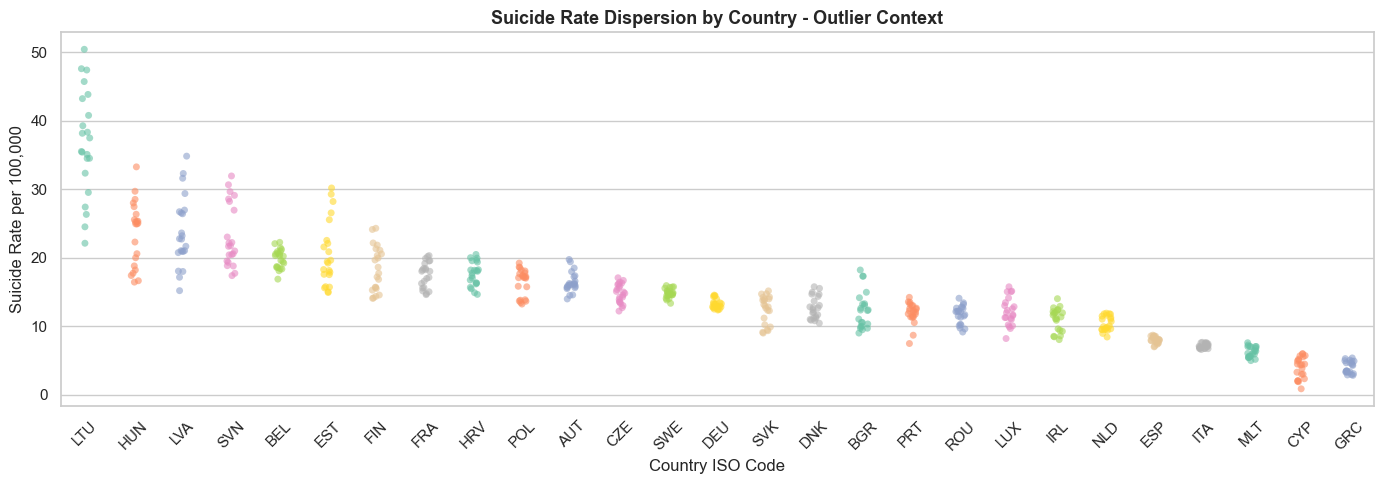

In [93]:
# ==============================================================================
# OUTLIER DETECTION (IQR-based)
# ==============================================================================


def flag_outliers_iqr(df, columns, threshold=1.5):
    """
    Flags rows as outliers using the IQR method for the specified columns.

    Parameters:
    -----------
    df : pd.DataFrame
    columns : list of str
        Columns to check for outliers.
    threshold : float
        IQR multiplier (1.5 = standard, 3.0 = extreme only).

    Returns:
    --------
    pd.DataFrame with count and percentage of outlier rows per feature.
    """
    results = []
    for col in columns:
        if col not in df.columns:
            continue
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - threshold * iqr
        upper = q3 + threshold * iqr
        mask = (df[col] < lower) | (df[col] > upper)
        results.append(
            {
                "Feature": col,
                "Outlier count": mask.sum(),
                "Outlier %": round(mask.sum() / len(df) * 100, 2),
                "Lower bound": round(lower, 2),
                "Upper bound": round(upper, 2),
            }
        )
    return pd.DataFrame(results).sort_values("Outlier count", ascending=False)


socioeconomic_cols_for_outliers = [
    c for c in social_economic_features if c in df_development.columns
]

outlier_summary = flag_outliers_iqr(df_development, socioeconomic_cols_for_outliers)
print("Outlier Summary (IQR method, threshold=1.5):")
display(outlier_summary)

# Stripplot to visually contextualise suicide rate outliers by country
fig, ax = plt.subplots(figsize=(14, 5))
sns.stripplot(
    data=df_development,
    x="Code",
    y="Suicide rate",
    order=df_development.groupby("Code")["Suicide rate"]
    .median()
    .sort_values(ascending=False)
    .index,
    jitter=True,
    alpha=0.6,
    palette="Set2",
    ax=ax,
)
ax.set_title(
    "Suicide Rate Dispersion by Country - Outlier Context",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Country ISO Code")
ax.set_ylabel("Suicide Rate per 100,000")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Multicollinearity check

Variance Inflation Factor (VIF) - Full predictor set:


,Feature,VIF
0,Eating disorders,12.082971
1,Attention-deficit/hyperactivity disorder,6.098285
2,Autism spectrum disorders,5.789120
3,GDP per capita,5.672588
4,Alzheimer's disease and other dementias,3.932731
5,Health expenditure (% GDP),3.755601
6,Bipolar disorder,3.648373
7,Internet users (% of population),3.100497
8,Urban population (%),3.091083
9,Conduct disorder,2.927916


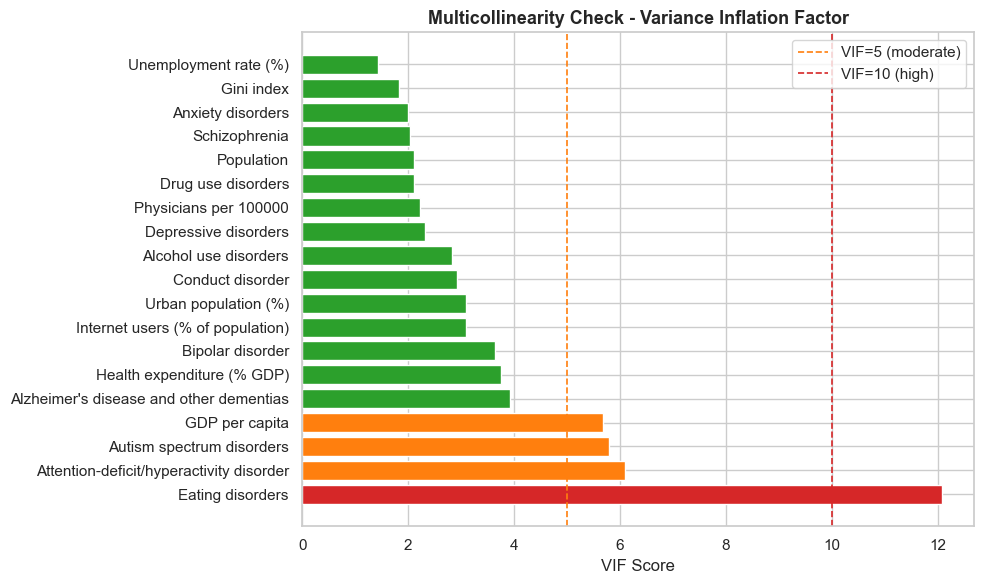

In [94]:
# ==============================================================================
# MULTICOLLINEARITY CHECK (Variance Inflation Factor)
# VIF > 5: moderate concern; VIF > 10: high concern
# ==============================================================================


def compute_vif(df, feature_cols):
    """
    Computes the Variance Inflation Factor (VIF) for each predictor.
    High VIF indicates multicollinearity with other predictors.
    """
    X = df[feature_cols].dropna()
    X_const = add_constant(X)
    vif_data = (
        pd.DataFrame(
            {
                "Feature": X.columns,
                "VIF": [
                    variance_inflation_factor(X_const.values, i + 1)
                    for i in range(len(X.columns))
                ],
            }
        )
        .sort_values("VIF", ascending=False)
        .reset_index(drop=True)
    )
    return vif_data


vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

### Addressing high multicollinearity: dropping Eating disorders
Since there is a value with high VIF, meaning it shares so much variance with other predictors that it adds almost no independent information to the model, it is decided to drop 'Eating disorders'

Variance Inflation Factor (VIF) - Full predictor set:


,Feature,VIF
0,Autism spectrum disorders,5.006914
1,Attention-deficit/hyperactivity disorder,4.622119
2,Alzheimer's disease and other dementias,3.891740
3,Health expenditure (% GDP),3.755597
4,GDP per capita,3.272651
5,Urban population (%),3.086496
6,Conduct disorder,2.922833
7,Internet users (% of population),2.915365
8,Bipolar disorder,2.867809
9,Alcohol use disorders,2.687695


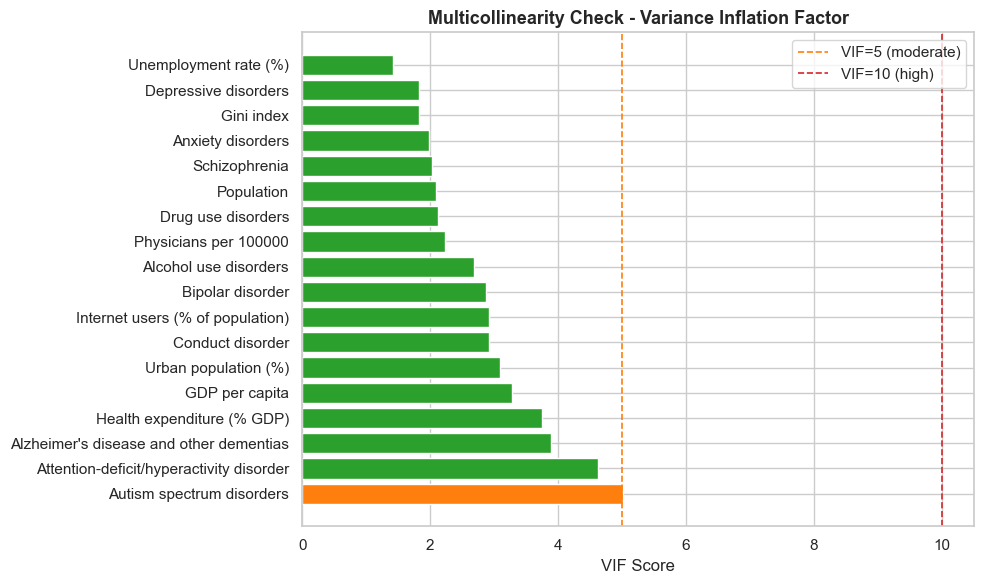

In [95]:
df_development.drop(columns=["Eating disorders"], inplace=True)
predictor_features = [c for c in df_development.columns if c not in ID_COLS + [TARGET]]

vif_results = compute_vif(df_development, predictor_features)
print("Variance Inflation Factor (VIF) - Full predictor set:")
display(vif_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [
    "#d62728" if v > 10 else "#ff7f0e" if v > 5 else "#2ca02c"
    for v in vif_results["VIF"]
]
ax.barh(vif_results["Feature"], vif_results["VIF"], color=colors)
ax.axvline(
    x=5, color="#ff7f0e", linestyle="--", linewidth=1.2, label="VIF=5 (moderate)"
)
ax.axvline(x=10, color="#d62728", linestyle="--", linewidth=1.2, label="VIF=10 (high)")
ax.set_xlabel("VIF Score")
ax.set_title(
    "Multicollinearity Check - Variance Inflation Factor",
    fontsize=13,
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

## Two approaches: 
- Option A. Geographical division. In this approach, we take 70% of the countries for training, and we try to predict "unknown" countries with what we learnt from those countries. This way we want to be able to predict the suicide rates of a country only knowing their socioeconomic and health data.
- Option B. Time division. In this approach, we take 70% of the years for all countries for training, and we try to predict the suicide rate in the upcoming years. 

The development dataset (2000–2021) is used for both approaches.
Years 2022–2023 are excluded as WHO suicide rate data is unavailable for that period.

### OPTION A - Geographical division

In [96]:
np.random.shuffle(EU_countries_iso)

# Division 70% Train, 15% Test, 15% Validation (countries)
total_countries = len(EU_countries_iso)
train_split = int(total_countries * 0.70)
test_split = int(total_countries * 0.85)

train_countries = EU_countries_iso[:train_split]
test_countries = EU_countries_iso[train_split:test_split]
val_countries = EU_countries_iso[test_split:]

# Creating the subsets for Option A
df_train_A = df_development[df_development["Code"].isin(train_countries)].copy()
df_test_A = df_development[df_development["Code"].isin(test_countries)].copy()
df_val_A = df_development[df_development["Code"].isin(val_countries)].copy()

print(f"Train countries ({len(train_countries)}): {train_countries}")
print(f"Test  countries ({len(test_countries)}):  {test_countries}")
print(f"Val   countries ({len(val_countries)}):   {val_countries}")
print(
    f"\nTrain: {len(df_train_A)} rows | Test: {len(df_test_A)} rows | Val: {len(df_val_A)} rows"
)
display(df_train_A.head(3))

Train countries (18): ['MLT', 'SVK', 'LTU', 'ITA', 'GRC', 'CZE', 'FIN', 'SVN', 'ROU', 'NLD', 'LVA', 'BEL', 'CYP', 'LUX', 'FRA', 'POL', 'HRV', 'DNK']
Test  countries (4):  ['BGR', 'PRT', 'ESP', 'HUN']
Val   countries (5):   ['EST', 'IRL', 'DEU', 'SWE', 'AUT']

Train: 396 rows | Test: 88 rows | Val: 110 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
24,Belgium,BEL,2000,2756.839586,1358.343233,4638.368645,905.124576,705.757518,712.835790,400.339867,3356.072780,861.473585,335.457189,23098.886508,6.586,7.999176,10251250.0,33.100000,82.015252,29.431692,282.9,22.066446,Western Europe/Nordics
25,Belgium,BEL,2001,2742.250875,1379.930669,4654.220915,901.854461,707.071240,711.290109,400.061362,3363.006903,858.273779,336.135116,23015.071263,6.178,8.149889,10286570.0,31.433333,82.335689,31.288396,284.9,22.254924,Western Europe/Nordics
26,Belgium,BEL,2002,2709.540349,1402.582939,4671.415432,898.653329,708.532961,707.756966,399.714573,3317.005557,856.860728,337.067605,25006.191397,6.910,8.318211,10332785.0,29.766667,82.650966,46.330000,285.9,20.961368,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

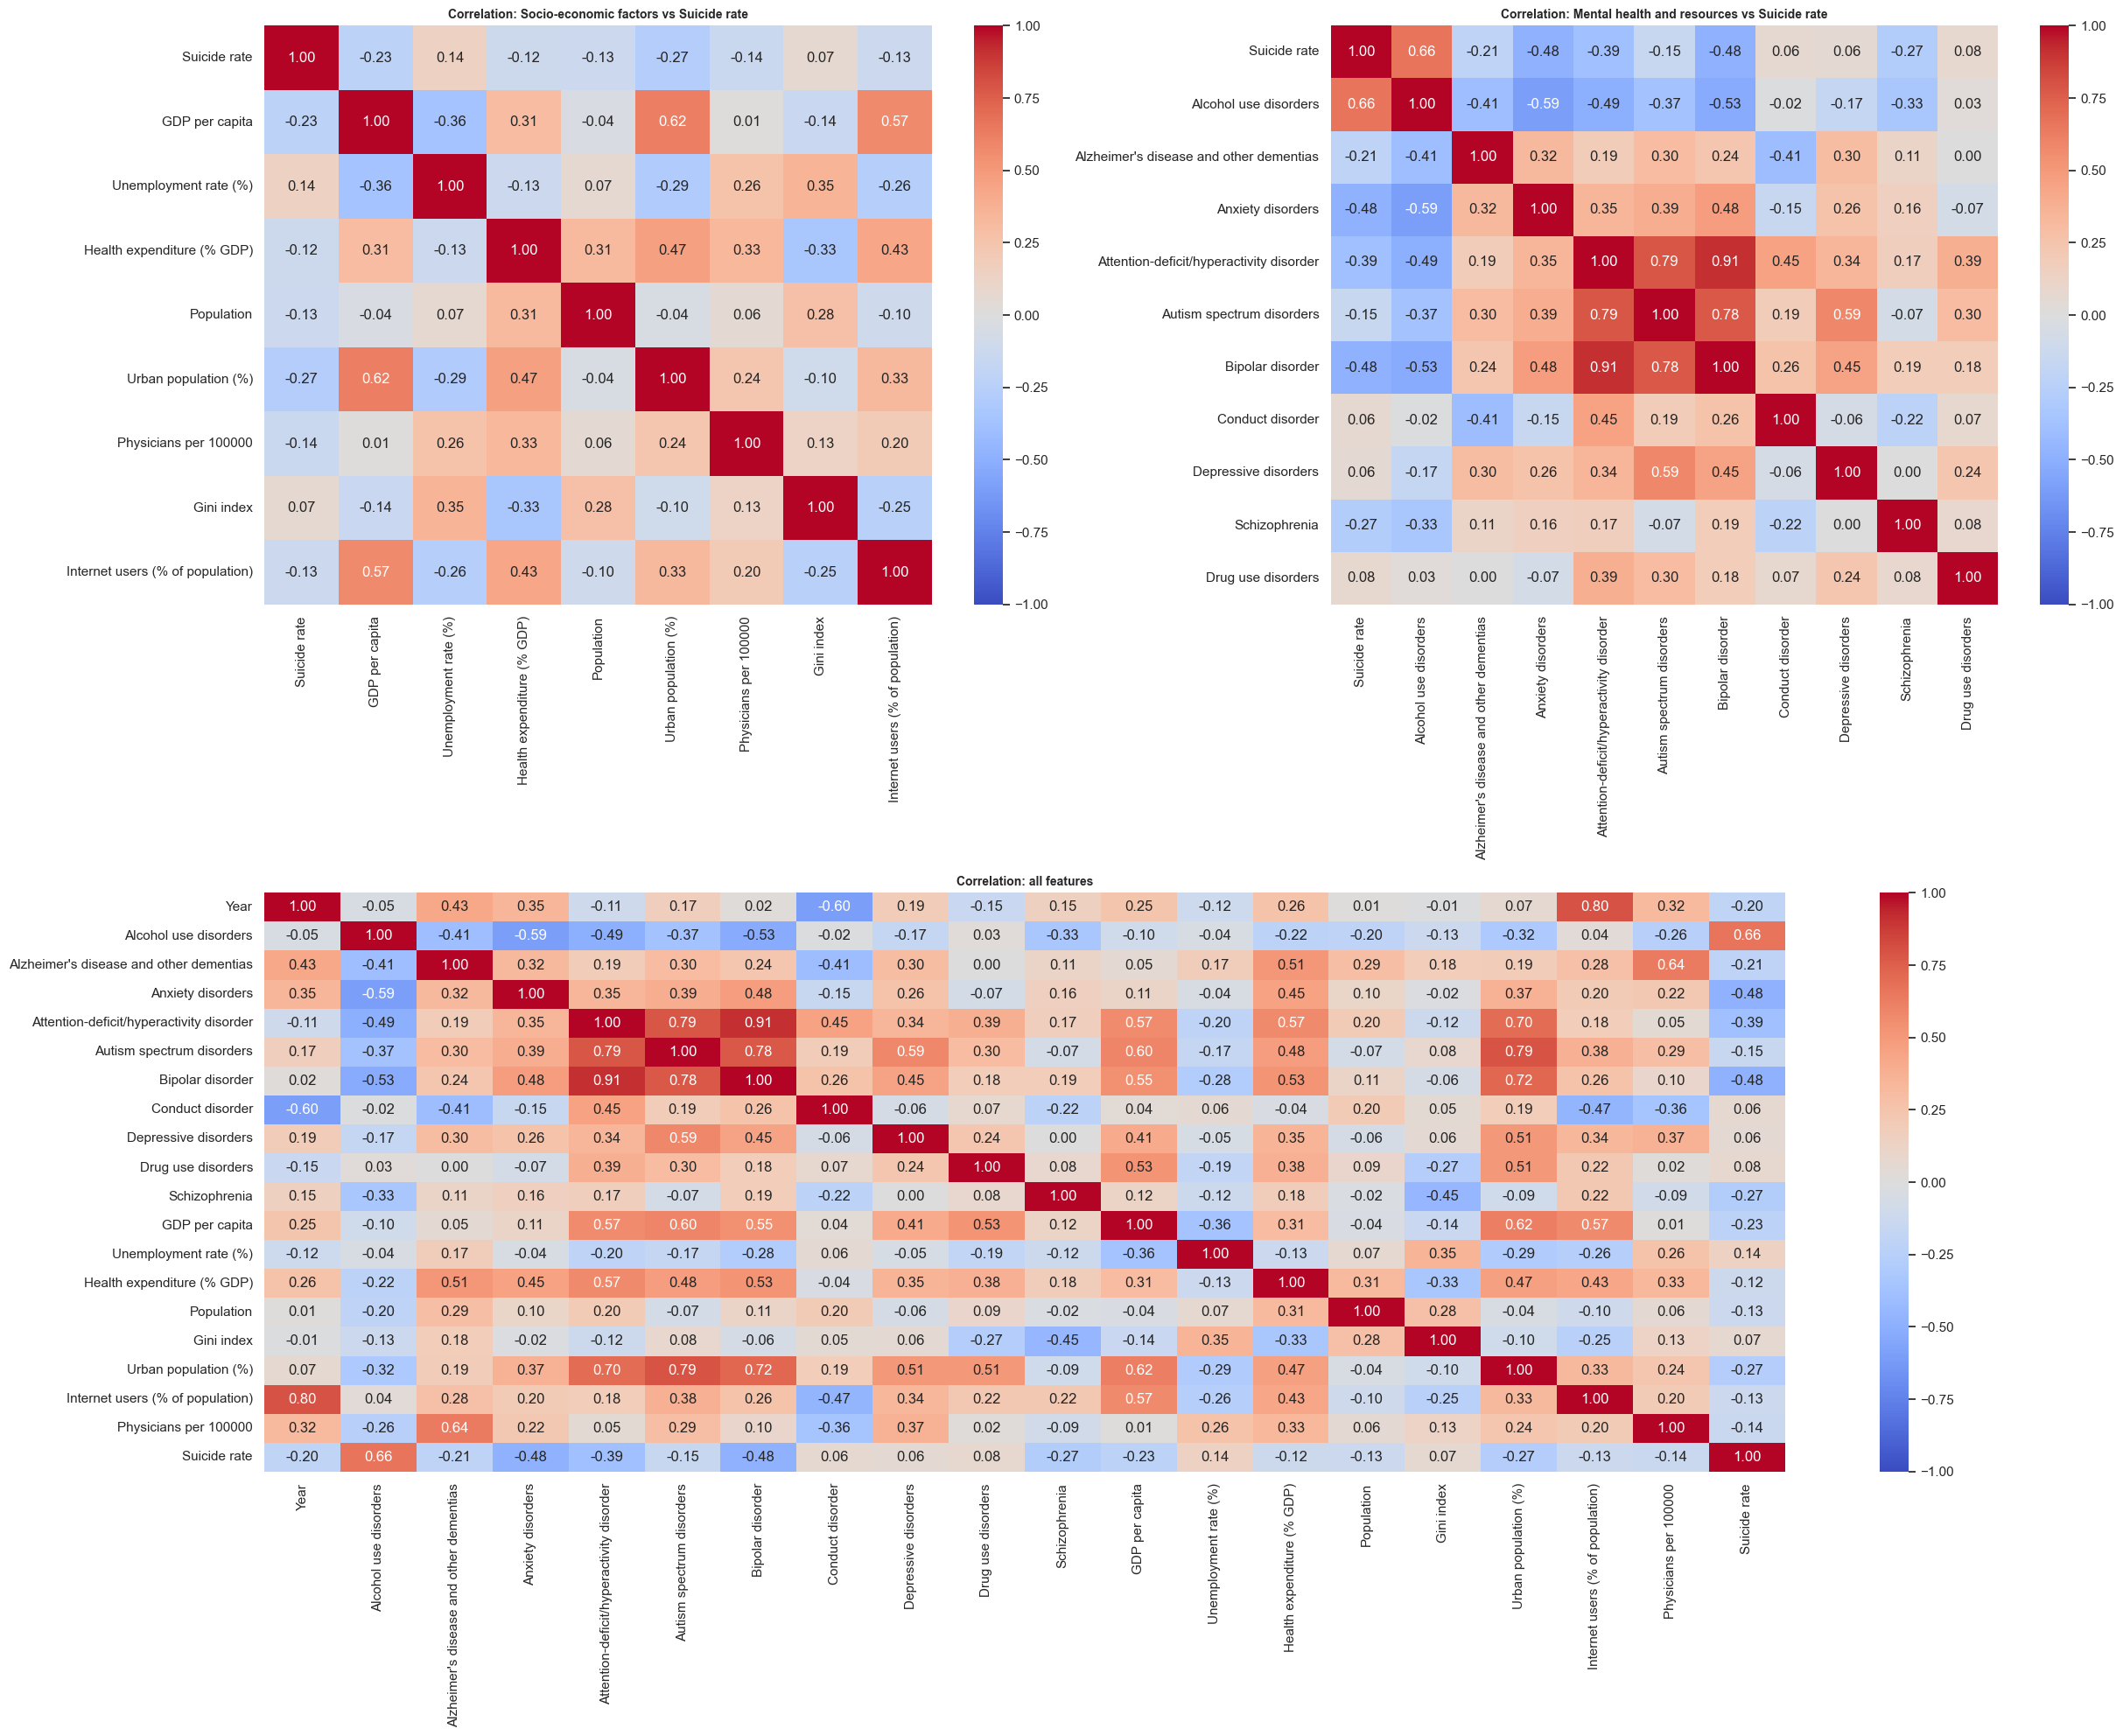

In [97]:
# ==============================================================================
# CORRELATION ANALYSIS
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_A[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_A[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_A.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set A

In [98]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option A: fit on train_A, transform test_A and val_A
scaler_A = RobustScaler()

X_train_A = df_train_A[predictor_features].copy()
X_test_A = df_test_A[predictor_features].copy()
X_val_A = df_val_A[predictor_features].copy()

y_train_A = df_train_A[TARGET].copy()
y_test_A = df_test_A[TARGET].copy()
y_val_A = df_val_A[TARGET].copy()

X_train_A_scaled = pd.DataFrame(
    scaler_A.fit_transform(X_train_A),
    columns=predictor_features,
    index=X_train_A.index,
)
X_test_A_scaled = pd.DataFrame(
    scaler_A.transform(X_test_A),
    columns=predictor_features,
    index=X_test_A.index,
)
X_val_A_scaled = pd.DataFrame(
    scaler_A.transform(X_val_A),
    columns=predictor_features,
    index=X_val_A.index,
)

print(" OPTION A - Scaled dataset shapes")
print(f"X_train_A: {X_train_A_scaled.shape}  |  y_train_A: {y_train_A.shape}")
print(f"X_test_A:  {X_test_A_scaled.shape}   |  y_test_A:  {y_test_A.shape}")
print(f"X_val_A:   {X_val_A_scaled.shape}    |  y_val_A:   {y_val_A.shape}")
display(X_train_A_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train A) — median ~0, IQR ~1:")
sanity_A = pd.DataFrame(
    {
        "Median": X_train_A_scaled.median().round(3),
        "IQR": (
            X_train_A_scaled.quantile(0.75) - X_train_A_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_A)

 OPTION A - Scaled dataset shapes
X_train_A: (396, 18)  |  y_train_A: (396,)
X_test_A:  (88, 18)   |  y_test_A:  (88,)
X_val_A:   (110, 18)    |  y_val_A:   (110,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,396.0,-0.011,0.559,-0.941,-0.598,0.0,0.402,1.138
Alzheimer's disease and other dementias,396.0,0.151,0.762,-0.979,-0.434,-0.0,0.566,2.822
Anxiety disorders,396.0,0.131,0.721,-1.024,-0.437,0.0,0.563,3.080
Attention-deficit/hyperactivity disorder,396.0,-0.111,0.539,-0.782,-0.674,0.0,0.326,0.826
Autism spectrum disorders,396.0,-0.226,0.509,-1.080,-0.796,0.0,0.204,0.558
Bipolar disorder,396.0,-0.121,0.523,-0.923,-0.690,0.0,0.310,0.904
Conduct disorder,396.0,0.079,0.811,-1.297,-0.467,0.0,0.533,2.691
Depressive disorders,396.0,0.067,0.739,-0.878,-0.512,0.0,0.488,3.192
Drug use disorders,396.0,-0.091,0.748,-2.208,-0.538,0.0,0.462,1.347
Schizophrenia,396.0,-0.021,1.083,-2.297,-0.418,-0.0,0.582,2.672



Scaling sanity check (train A) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,-0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,0.0,1.0
Schizophrenia,-0.0,1.0


### OPTION B - Time division
All 27 countries are included across all splits. The model learns temporal patterns from earlier years and is evaluated on its ability to generalise to more recent periods.

In [99]:
# Division 70% Train, 15% Test, 15% Validation (years)
year_range = sorted(df_development["Year"].unique())
total_years = len(year_range)
train_split = int(total_years * 0.70)
test_split = int(total_years * 0.85)

train_years = year_range[:train_split]
test_years = year_range[train_split:test_split]
val_years = year_range[test_split:]

# Creating the subsets for Option B
df_train_B = df_development[df_development["Year"].isin(train_years)].copy()
df_test_B = df_development[df_development["Year"].isin(test_years)].copy()
df_val_B = df_development[df_development["Year"].isin(val_years)].copy()

print(f"Train years: {train_years}")
print(f"Test  years: {test_years}")
print(f"Val   years: {val_years}")
print(
    f"\nTrain: {len(df_train_B)} rows | Test: {len(df_test_B)} rows | Val: {len(df_val_B)} rows"
)
display(df_train_B.head(3))

Train years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014)]
Test  years: [np.int64(2015), np.int64(2016), np.int64(2017)]
Val   years: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]

Train: 405 rows | Test: 81 rows | Val: 108 rows


,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics


In [100]:
df_train_B

,Country,Code,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Region
0,Austria,AUT,2000,3191.951091,1132.966544,4024.482195,1175.534494,721.252486,720.168715,395.555429,2408.933392,881.662224,340.766068,24487.297469,4.687,9.389345,8011566.0,29.000000,66.769024,33.730133,387.6,19.753390,Western Europe/Nordics
1,Austria,AUT,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.185450,398.9,18.508048,Western Europe/Nordics
2,Austria,AUT,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.560000,406.0,19.413281,Western Europe/Nordics
3,Austria,AUT,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.700000,414.4,17.989560,Western Europe/Nordics
4,Austria,AUT,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.280000,423.2,17.383069,Western Europe/Nordics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,Sweden,SWE,2010,3471.778602,1289.716279,3579.974770,835.674260,1010.913479,703.278650,380.487968,3989.740920,728.685873,291.725127,52542.575909,8.610,8.323847,9378126.0,27.700000,85.133423,90.000000,380.8,14.611551,Western Europe/Nordics
635,Sweden,SWE,2011,3493.057811,1288.184612,3650.800966,832.880132,1011.088822,702.374974,375.105420,3755.514084,749.972402,291.644800,60379.481460,7.804,10.501790,9449213.0,27.600000,85.360075,92.769986,388.8,14.070399,Western Europe/Nordics
636,Sweden,SWE,2012,3537.463354,1294.691436,3778.530954,831.071887,1010.582972,700.956136,371.999891,4009.199832,781.377987,291.383413,57749.561542,7.976,10.834198,9519374.0,27.600000,85.625067,93.179988,396.7,14.860432,Western Europe/Nordics
637,Sweden,SWE,2013,3587.706626,1288.475264,3922.330634,830.817735,1010.292831,699.554932,371.250247,3856.467417,817.474462,291.065042,60843.988880,8.052,10.987218,9600379.0,28.800000,85.924977,94.783600,404.3,15.775550,Western Europe/Nordics


Correlation matrices are computed exclusively on the training set to prevent any information from the test or validation sets influencing the EDA.

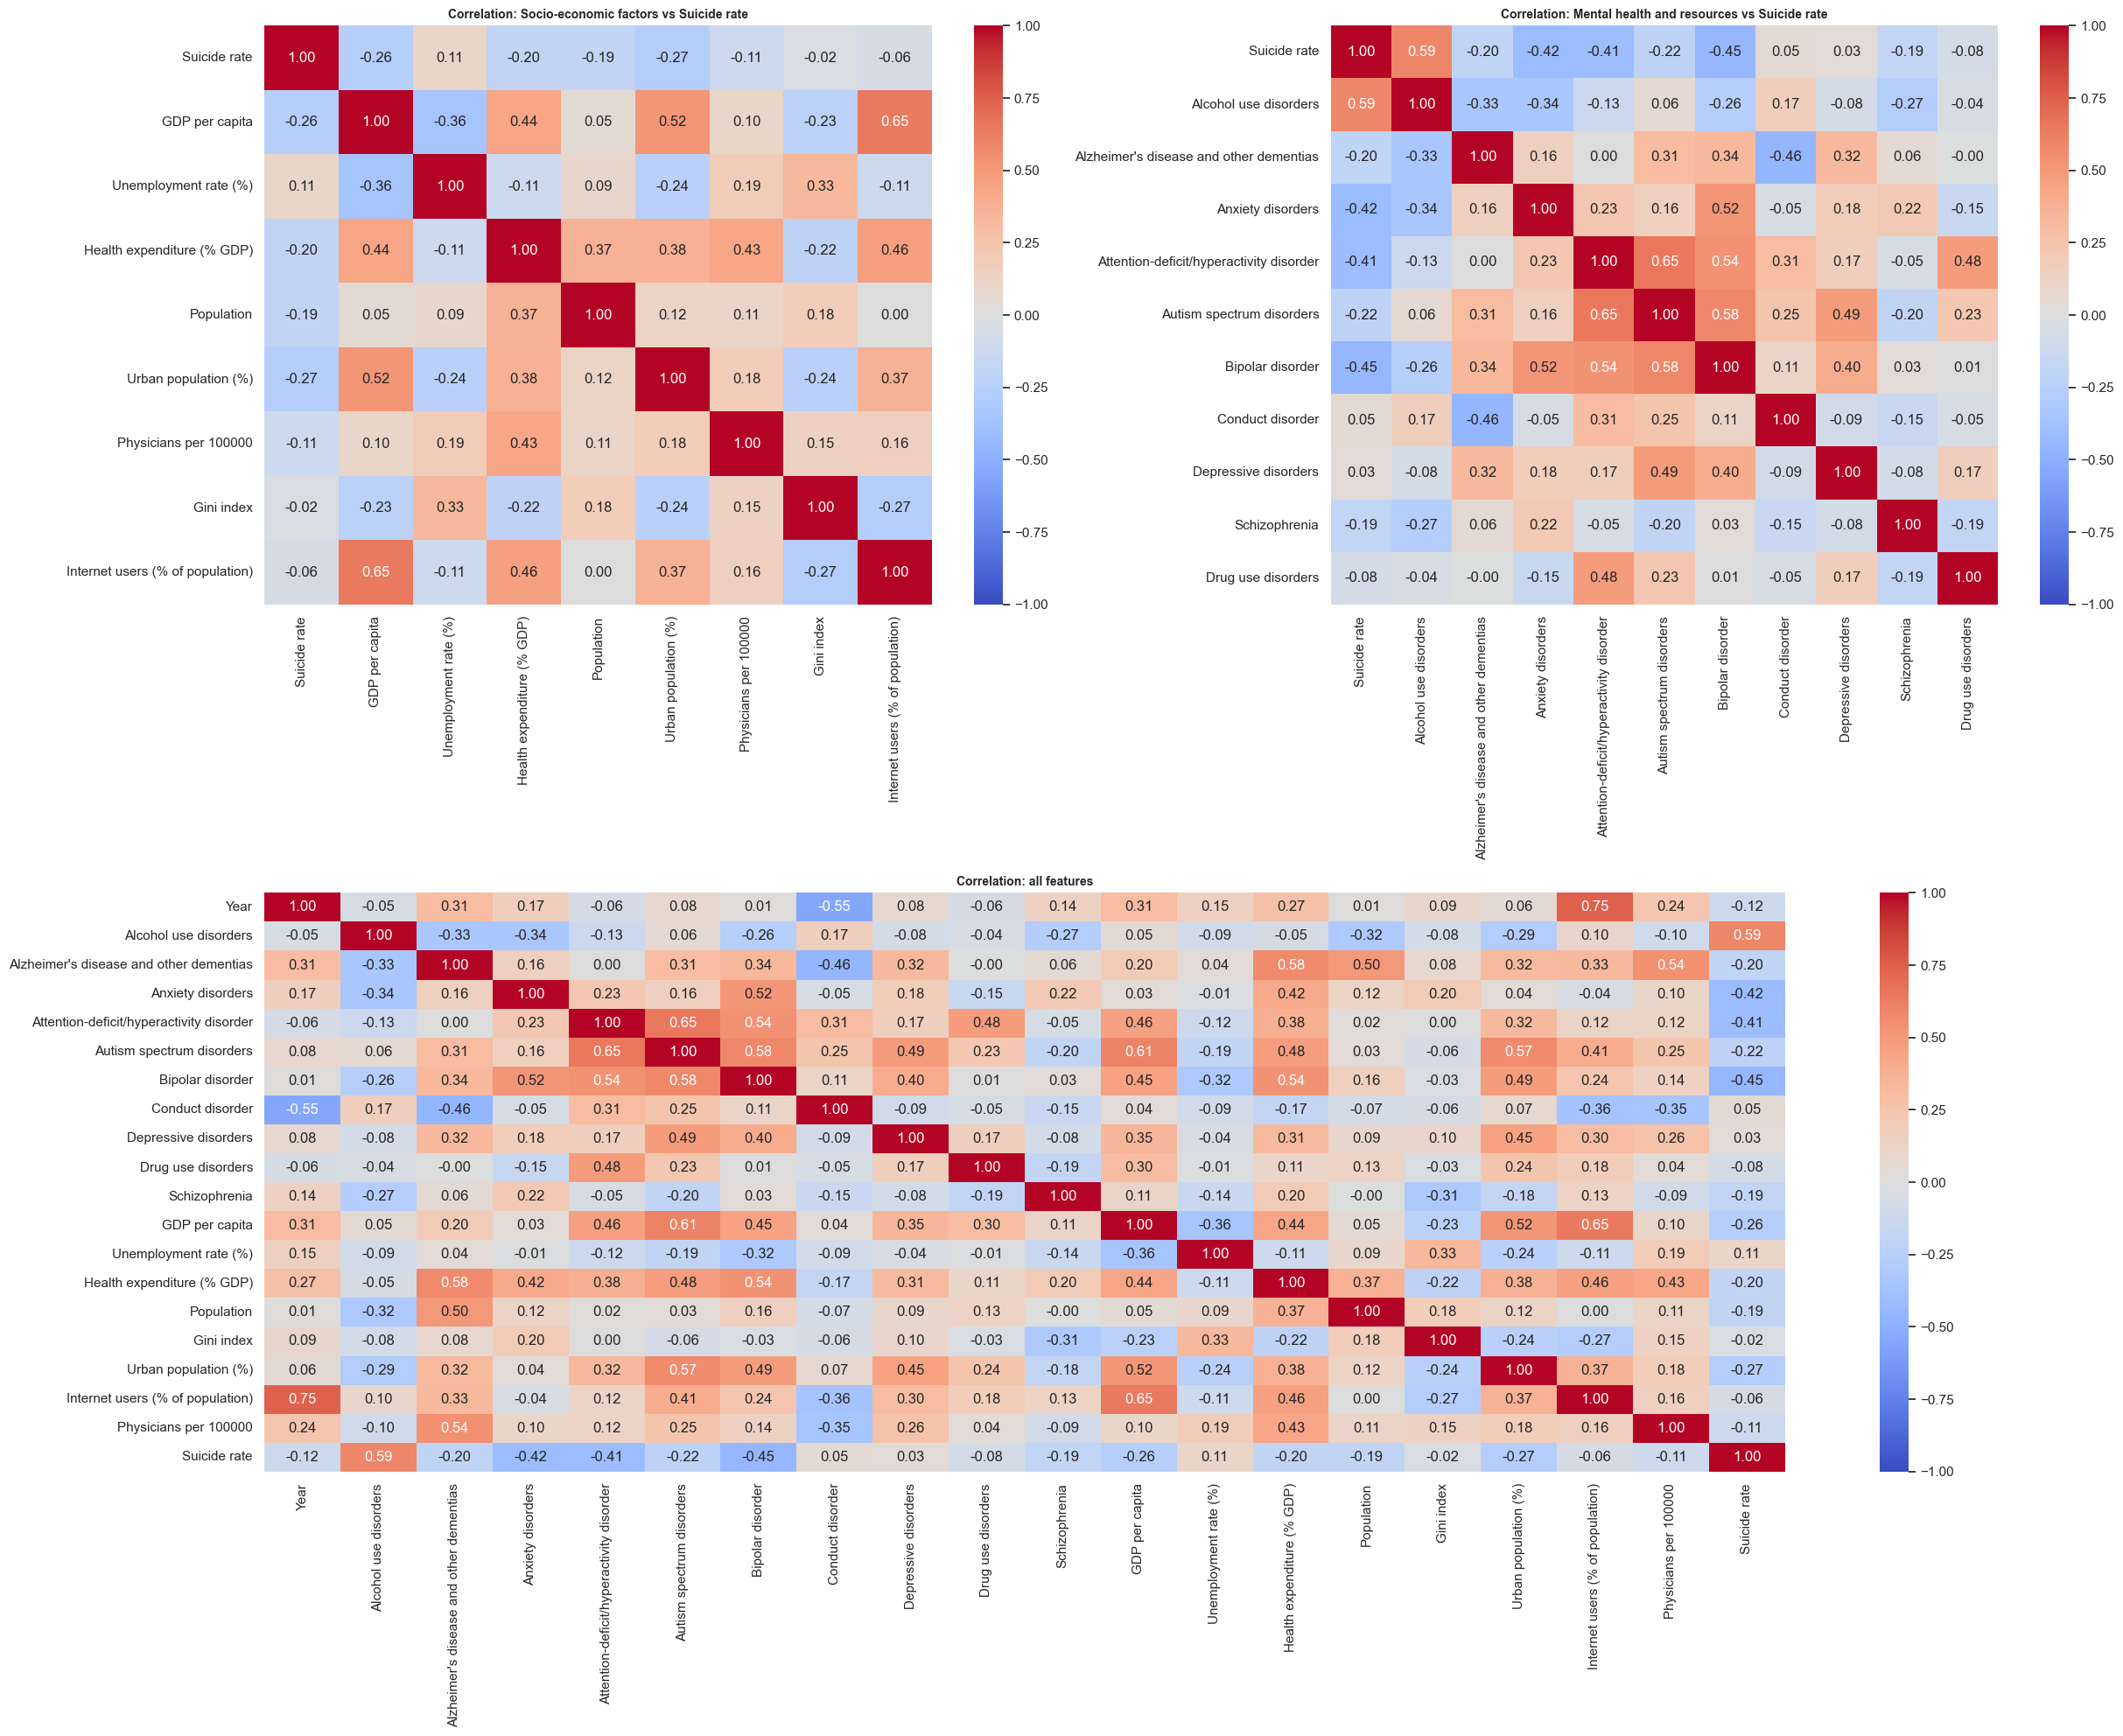

In [101]:
# ==============================================================================
# CORRELATION ANALYSIS FOR SET B
# Computed on training set only to prevent data leakage into test/val
# ==============================================================================

fig, axs = plt.subplot_mosaic(
    [["top_left", "top_right"], ["bottom", "bottom"]], figsize=(25, 20)
)
sns.heatmap(
    df_train_B[social_economic_features].corr(),
    ax=axs["top_left"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_left"].set_title(
    "Correlation: Socio-economic factors vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

sns.heatmap(
    df_train_B[health_related_features].corr(),
    ax=axs["top_right"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["top_right"].set_title(
    "Correlation: Mental health and resources vs Suicide rate",
    fontsize=10,
    fontweight="bold",
)

corr_matrix = df_train_B.select_dtypes(include=[np.number]).corr()
sns.heatmap(
    corr_matrix,
    ax=axs["bottom"],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
axs["bottom"].set_title(
    "Correlation: all features",
    fontsize=10,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

### Feature scaling for set B

In [102]:
# ==============================================================================
# Scaling the data. Using RobustScaler because as described before, the dataset
# contains several outliers and therefore using the median and IQR will not be
# affected by extreme values.
# ==============================================================================

# Option B: fit on train_B, transform test_B and val_B
scaler_B = RobustScaler()

X_train_B = df_train_B[predictor_features].copy()
X_test_B = df_test_B[predictor_features].copy()
X_val_B = df_val_B[predictor_features].copy()

y_train_B = df_train_B[TARGET].copy()
y_test_B = df_test_B[TARGET].copy()
y_val_B = df_val_B[TARGET].copy()

X_train_B_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_train_B),
    columns=predictor_features,
    index=X_train_B.index,
)
X_test_B_scaled = pd.DataFrame(
    scaler_B.transform(X_test_B),
    columns=predictor_features,
    index=X_test_B.index,
)
X_val_B_scaled = pd.DataFrame(
    scaler_B.transform(X_val_B),
    columns=predictor_features,
    index=X_val_B.index,
)

print(" OPTION B - Scaled dataset shapes")
print(f"X_train_B: {X_train_B_scaled.shape}  |  y_train_B: {y_train_B.shape}")
print(f"X_test_B:  {X_test_B_scaled.shape}   |  y_test_B:  {y_test_B.shape}")
print(f"X_val_B:   {X_val_B_scaled.shape}    |  y_val_B:   {y_val_B.shape}")
display(X_train_B_scaled.describe().T.round(3))

# Sanity check: after RobustScaler, median should be ~0 and IQR should be ~1 on train
print("\nScaling sanity check (train B) — median ~0, IQR ~1:")
sanity_B = pd.DataFrame(
    {
        "Median": X_train_B_scaled.median().round(3),
        "IQR": (
            X_train_B_scaled.quantile(0.75) - X_train_B_scaled.quantile(0.25)
        ).round(3),
    }
)
display(sanity_B)

 OPTION B - Scaled dataset shapes
X_train_B: (405, 18)  |  y_train_B: (405,)
X_test_B:  (81, 18)   |  y_test_B:  (81,)
X_val_B:   (108, 18)    |  y_val_B:   (108,)


,count,mean,std,min,25%,50%,75%,max
Alcohol use disorders,405.0,-0.002,0.657,-1.215,-0.474,0.0,0.526,1.197
Alzheimer's disease and other dementias,405.0,0.167,0.785,-1.054,-0.434,0.0,0.566,3.163
Anxiety disorders,405.0,0.213,0.795,-1.013,-0.364,0.0,0.636,2.994
Attention-deficit/hyperactivity disorder,405.0,-0.089,0.661,-1.057,-0.681,0.0,0.319,1.633
Autism spectrum disorders,405.0,-0.189,0.621,-1.195,-0.841,0.0,0.159,1.508
Bipolar disorder,405.0,-0.124,0.582,-1.178,-0.698,0.0,0.302,1.135
Conduct disorder,405.0,0.054,0.791,-1.549,-0.486,0.0,0.514,2.529
Depressive disorders,405.0,0.006,0.690,-1.058,-0.560,0.0,0.440,2.324
Drug use disorders,405.0,0.068,0.886,-1.921,-0.541,0.0,0.459,3.414
Schizophrenia,405.0,-0.108,0.936,-1.943,-0.534,0.0,0.466,2.410



Scaling sanity check (train B) — median ~0, IQR ~1:


,Median,IQR
Alcohol use disorders,0.0,1.0
Alzheimer's disease and other dementias,0.0,1.0
Anxiety disorders,0.0,1.0
Attention-deficit/hyperactivity disorder,0.0,1.0
Autism spectrum disorders,0.0,1.0
Bipolar disorder,0.0,1.0
Conduct disorder,0.0,1.0
Depressive disorders,0.0,1.0
Drug use disorders,0.0,1.0
Schizophrenia,0.0,1.0


--------------------------------


In [103]:
from catboost import CatBoostRegressor
import shap


## We evaluate a CatBoost model for predicting the suicide rate.

CatBoost is well-suited for this task because it natively handles categorical variables (e.g., country) without requiring one-hot encoding. This avoids increasing dimensionality and prevents issues related to high-cardinality categorical features.

In addition, CatBoost does not require feature scaling, since tree-based models are not sensitive to variable magnitude. However, we reuse the already scaled dataset for consistency with the rest of the pipeline and to keep preprocessing steps uniform across experiments.

The model is expected to capture non-linear relationships between socioeconomic factors and suicide rates, as well as complex feature interactions, leveraging the strengths of gradient boosting methods

In [104]:
X_train_cat = X_train_B_scaled.copy()
X_test_cat = X_test_B_scaled.copy()
X_val_cat = X_val_B_scaled.copy()

X_train_cat["Year"] = df_train_B["Year"]
X_test_cat["Year"] = df_test_B["Year"]
X_val_cat["Year"] = df_val_B["Year"]

X_train_cat["Country"] = df_train_B["Country"]
X_test_cat["Country"] = df_test_B["Country"]
X_val_cat["Country"] = df_val_B["Country"]

In [105]:
X_train_cat.head()

,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Year,Country
0,0.523539,0.304534,-0.265258,0.631631,-0.017319,0.327250,0.236096,-0.869238,0.102540,-0.157114,0.060495,-0.634305,0.564530,-0.022164,-0.355932,-0.093724,-0.585337,0.659243,2000,Austria
1,0.525366,0.333423,-0.250953,0.627781,-0.008040,0.324440,0.212150,-0.863657,0.081677,-0.127725,0.058445,-0.768216,0.587296,-0.019765,-0.327684,-0.089743,-0.438592,0.785078,2001,Austria
2,0.528300,0.370314,-0.236547,0.628249,0.001912,0.307711,0.155284,-0.856927,0.054132,-0.097176,0.127173,-0.601812,0.637441,-0.016669,-0.299435,-0.087086,-0.509215,0.864143,2002,Austria
3,0.533001,0.385463,-0.215433,0.629444,0.014595,0.287406,0.077656,-0.851985,0.026869,-0.064431,0.335600,-0.616187,0.676068,-0.013588,-0.271186,-0.085000,-0.344053,0.957684,2003,Austria
4,0.538322,0.384719,-0.187187,0.627956,0.028694,0.273227,0.001634,-0.848715,0.005987,-0.033403,0.498153,-0.381843,0.718244,-0.009642,-0.220339,-0.083364,-0.032558,1.055679,2004,Austria


We explicitly define country as a categorical feature, ensuring CatBoost can properly leverage its native handling of categorical variables without additional encoding.

We then initialize the CatBoost model, configuring it to recognize the categorical feature set during training.

In [106]:
for df in [X_train_cat, X_test_cat, X_val_cat]:
    df["Country"] = df["Country"].astype("category")

cat_features = ["Country"]

### CatBoost MODEL


In [107]:
model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

We train the model and evaluate its performance on both the training and validation sets using Root Mean Squared Error (RMSE), where lower values indicate better performance.

During training, CatBoost reports three key metrics:

 - learn: training error, computed on the data used to fit the model. It measures how well the model is fitting the training set.
 - test: validation error, computed on the eval_set. It reflects generalization performance; divergence from learn can indicate overfitting.
 - best: the best validation score achieved during training up to that point.

Interpretation of the training dynamics:

 - learn ↓ significantly and test ↑ → overfitting
 - learn ↓ and test ↓ → good generalization and useful model
 - learn ↓ and test stagnates → model has likely reached its learning capacity

In [108]:
model.fit(
    X_train_cat,
    y_train_B,
    cat_features=cat_features,
    eval_set=(X_val_cat, y_val_B)
)

Learning rate set to 0.044184
0:	learn: 7.8436872	test: 5.6371434	best: 5.6371434 (0)	total: 22ms	remaining: 22s
100:	learn: 1.3839835	test: 3.1623507	best: 3.1623507 (100)	total: 2.83s	remaining: 25.2s
200:	learn: 0.9233939	test: 2.9719054	best: 2.9719054 (200)	total: 5.51s	remaining: 21.9s
300:	learn: 0.7432309	test: 2.8354767	best: 2.8354767 (300)	total: 8.19s	remaining: 19s
400:	learn: 0.6352657	test: 2.7770156	best: 2.7770156 (400)	total: 10.9s	remaining: 16.3s
500:	learn: 0.5597244	test: 2.7514052	best: 2.7514052 (500)	total: 13.5s	remaining: 13.5s
600:	learn: 0.4957104	test: 2.7363778	best: 2.7326215 (575)	total: 16.1s	remaining: 10.7s
700:	learn: 0.4427460	test: 2.7235115	best: 2.7224625 (693)	total: 18.5s	remaining: 7.9s
800:	learn: 0.3931987	test: 2.7117089	best: 2.7110131 (787)	total: 20.9s	remaining: 5.2s
900:	learn: 0.3536915	test: 2.7053650	best: 2.7046306 (885)	total: 23.6s	remaining: 2.59s
999:	learn: 0.3133897	test: 2.6911929	best: 2.6911929 (999)	total: 25.9s	remainin

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=100)

The results indicate that the model learns the training data very effectively:

 - Strong learning on the training set
 - Limited generalization improvement
 - Train–test gap: moderate overfitting
 - Overall interpretation

Main issues come from:

 - Limited data
 - Variables by country/year introducing strong correlations
 - Weak or partially informative features

### COMPARISON

We compute MAE, RMSE, and R² for the train, validation, and test sets in order to systematically compare model performance across different data splits.

These metrics provide complementary perspectives:

 - MAE (Mean Absolute Error): average magnitude of errors in absolute terms, less sensitive to outliers.
 - RMSE (Root Mean Squared Error): penalizes larger errors more heavily, making it useful to detect poorly fitted predictions.
 - R² (coefficient of determination): measures the proportion of variance explained by the model.

All results are consolidated into a DataFrame, enabling a clear and structured comparison of performance across datasets and metrics.

In [172]:
## TRAIN ##

y_train_pred = model.predict(X_train_cat)


mae_train = mean_absolute_error(y_train_B, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_B, y_train_pred))
r2_train = r2_score(y_train_B, y_train_pred)


## TEST ##

y_pred = model.predict(X_test_cat)

mae = mean_absolute_error(y_test_B, y_pred)
rmse =  np.sqrt(mean_squared_error(y_test_B, y_pred))
r2 = r2_score(y_test_B, y_pred)

## VALIDATION ##

y_val_pred = model.predict(X_val_cat)

mae_val = mean_absolute_error(y_val_B, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val_B, y_val_pred))
r2_val = r2_score(y_val_B, y_val_pred)

In [ ]:
metrics_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "MAE": [mae_train, mae_val, mae],
    "RMSE": [rmse_train, rmse_val, rmse],
    "R²": [r2_train, r2_val, r2]
})

metrics_df = metrics_df.round(3)

metrics_df

,Dataset,MAE,RMSE,R²
0,Train,0.263,0.365,0.998
1,Validation,2.156,2.691,0.673
2,Test,1.399,1.794,0.903


The comparison shows signs of overfitting, so we inspect the model further by analyzing feature importance to understand which variables have the greatest influence on its predictions.

In [114]:
importance = model.get_feature_importance()

importance_df = pd.DataFrame({
    "Feature": X_train_cat.columns,
    "Importance": importance
}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
19,Country,22.024031
0,Alcohol use disorders,14.525014
9,Schizophrenia,11.492883
13,Population,7.851620
8,Drug use disorders,6.604973
3,Attention-deficit/hyperactivity disorder,5.516558
7,Depressive disorders,4.968384
5,Bipolar disorder,3.990483
4,Autism spectrum disorders,3.185466
14,Gini index,2.896214


We repeat the experiment using the same CatBoost configuration, but removing country from the feature set due to its high importance in the previous model.

The goal is to evaluate whether the model was relying too heavily on this categorical variable and whether removing it improves generalization.

We then retrain the model and compare the results against the previous version to assess the impact on train, validation, and test performance.

### CatBoost MODEL without "Country"


In [115]:
X_train_cat_year = X_train_B_scaled.copy()
X_test_cat_year = X_test_B_scaled.copy()
X_val_cat_year = X_val_B_scaled.copy()

X_train_cat_year["Year"] = df_train_B["Year"]
X_test_cat_year["Year"] = df_test_B["Year"]
X_val_cat_year["Year"] = df_val_B["Year"]




In [116]:
model_year = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [117]:
model_year.fit(
    X_train_cat_year,
    y_train_B,   
    eval_set=(X_val_cat_year, y_val_B)
)

Learning rate set to 0.044184
0:	learn: 7.8937672	test: 5.6044956	best: 5.6044956 (0)	total: 3.2ms	remaining: 3.2s
100:	learn: 1.2179469	test: 3.2075296	best: 3.2061494 (99)	total: 240ms	remaining: 2.14s
200:	learn: 0.6637335	test: 2.9330581	best: 2.9330581 (200)	total: 482ms	remaining: 1.92s
300:	learn: 0.5035202	test: 2.8431506	best: 2.8431506 (300)	total: 714ms	remaining: 1.66s
400:	learn: 0.4172880	test: 2.8272772	best: 2.8248397 (398)	total: 948ms	remaining: 1.42s
500:	learn: 0.3562295	test: 2.8095888	best: 2.8081571 (497)	total: 1.18s	remaining: 1.17s
600:	learn: 0.3040670	test: 2.8018916	best: 2.8005045 (598)	total: 1.41s	remaining: 938ms
700:	learn: 0.2624567	test: 2.7939781	best: 2.7915639 (689)	total: 1.65s	remaining: 704ms
800:	learn: 0.2284047	test: 2.7875458	best: 2.7875458 (800)	total: 1.89s	remaining: 469ms
900:	learn: 0.1998281	test: 2.7806736	best: 2.7797067 (891)	total: 2.12s	remaining: 233ms
999:	learn: 0.1758461	test: 2.7798380	best: 2.7793329 (928)	total: 2.35s	rem

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=100)

Removing country leads to a slight deterioration in generalization performance, indicating a reduced ability of the model to capture part of the underlying structural variability in the data.

However, the overall impact remains limited: differences between models with and without country are marginal, and the degree of overfitting is essentially unchanged. This suggests that country is not a key factor in controlling model generalization or reducing overfitting, but rather provides only incremental predictive information.

From a broader perspective, most of the explainable variance in suicide rates is already captured by the socio-economic variables. The model maintains strong predictive performance overall (R² ≈ 0.90 on the test set), and country behaves mainly as a weak proxy rather than a primary explanatory driver.

In [173]:
## TRAIN ##

y_train_pred_year = model_year.predict(X_train_cat_year)


mae_train_year = mean_absolute_error(y_train_B, y_train_pred_year)
rmse_train_year = np.sqrt(mean_squared_error(y_train_B, y_train_pred_year))
r2_train_year = r2_score(y_train_B, y_train_pred_year)


## TEST ##

y_pred_year = model_year.predict(X_test_cat_year)

mae_year = mean_absolute_error(y_test_B, y_pred_year)
rmse_year =  np.sqrt(mean_squared_error(y_test_B, y_pred_year))
r2_year = r2_score(y_test_B, y_pred_year)


## VALIDATION ##

y_val_pred_year = model_year.predict(X_val_cat_year)

mae_val_year = mean_absolute_error(y_val_B, y_val_pred_year)
rmse_val_year = np.sqrt(mean_squared_error(y_val_B, y_val_pred_year))
r2_val_year = r2_score(y_val_B, y_val_pred_year)

In [ ]:
metrics_df_year = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "MAE": [mae_train_year, mae_val_year, mae_year],
    "RMSE": [rmse_train_year, rmse_val_year, rmse_year],
    "R²": [r2_train_year, r2_val_year, r2_year]
})


metrics_df_year = metrics_df_year.round(3)

metrics_df_year

,Dataset,MAE,RMSE,R²
0,Train,0.160,0.194,0.999
1,Validation,2.225,2.779,0.651
2,Test,1.383,1.828,0.899


In [123]:
importance_year = model_year.get_feature_importance()

importance_df_year = pd.DataFrame({
    "Feature": X_train_cat_year.columns,
    "Importance": importance_year
}).sort_values(
    "Importance",
    ascending=False
)

importance_df_year.head(15)

,Feature,Importance
0,Alcohol use disorders,30.063589
3,Attention-deficit/hyperactivity disorder,10.649706
13,Population,10.103862
9,Schizophrenia,9.568147
5,Bipolar disorder,6.250692
8,Drug use disorders,5.818876
7,Depressive disorders,5.514724
4,Autism spectrum disorders,3.046251
15,Urban population (%),2.432909
10,GDP per capita,2.269085


Given these results, the next step is to extend the feature space rather than simplify it. A new model will be built reintroducing country and incorporating temporal lag features to explicitly capture the strong expected autocorrelation in suicide rates over time. This aims to better model temporal dependency structures and improve predictive performance by accounting for dynamics that static features alone cannot represent.


### CatBoost MODEL with "Country" and LAGS


We reproduce the previous CatBoost model, this time adding the suicide_rate_lag_1 feature, which contains the suicide rate from the previous year for each country.

This lag feature allows the model to explicitly capture the temporal dependency of the target variable, under the assumption that suicide rates are highly autocorrelated over time. By incorporating information from the previous year, we aim to improve the model's predictive performance and generalization.

In [124]:
df_lag = df_development.sort_values(["Country", "Year"])

df_lag = df_lag.drop(columns=["Code", "Region"])

In [125]:
df_lag["Suicide rate_lag_1"] = (
    df_lag.groupby("Country")["Suicide rate"].shift(1)
)



df_lag = df_lag.dropna().reset_index(drop=True)
df_lag.head()

,Country,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate,Suicide rate_lag_1
0,Austria,2001,3193.762279,1143.969355,4046.938653,1173.433463,723.015405,719.736433,394.027233,2414.230764,875.548127,342.045193,24430.495983,4.007,9.452435,8042293.0,29.166667,66.840816,39.18545,398.9,18.508048,19.753390
1,Austria,2002,3196.670699,1158.019381,4069.554739,1173.688637,724.906163,717.163393,390.398108,2420.619752,867.476203,343.374835,26334.862215,4.852,9.591399,8081957.0,29.333333,66.888746,36.56000,406.0,19.413281,18.508048
2,Austria,2003,3201.329520,1163.789032,4102.701811,1174.340827,727.316029,714.040173,385.443904,2425.310908,859.486814,344.800007,32110.115966,4.779,9.698442,8121423.0,29.500000,66.926357,42.70000,414.4,17.989560,19.413281
3,Austria,2004,3206.603569,1163.505776,4147.044336,1173.529004,729.994711,711.859272,380.592234,2428.414977,853.367328,346.150489,36614.250653,5.969,9.815324,8171966.0,29.800000,66.955861,54.28000,423.2,17.383069,17.989560
4,Austria,2005,3209.694457,1179.516201,4189.256997,1168.103300,732.050736,711.620535,376.216532,2432.497290,849.352348,347.085179,38157.370229,5.682,9.717797,8227829.0,28.700000,66.979795,58.00000,434.8,17.224047,17.383069


Redifine targets and split of data

In [126]:
y_lag = df_lag[TARGET]

X_lag = df_lag.drop(columns=[TARGET])


In [127]:
train_lag = df_lag[df_lag["Year"] <= 2014]
test_lag = df_lag[(df_lag["Year"] >= 2015) & (df_lag["Year"] <= 2017)]
val_lag = df_lag[df_lag["Year"] >= 2018]

In [128]:
X_train_lag = train_lag.drop(columns=[TARGET])
y_train_lag = train_lag[TARGET]

X_test_lag = test_lag.drop(columns=[TARGET])
y_test_lag = test_lag[TARGET]

X_val_lag = val_lag.drop(columns=[TARGET])
y_val_lag = val_lag[TARGET]

In [129]:
for df in [X_train_lag, X_test_lag, X_val_lag]:
    df_lag["Country"] = df_lag["Country"].astype("category")

cat_features = ["Country"]

SAME MODEL

In [130]:
model_lag = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=100
)

In [131]:
model_lag.fit(
    X_train_lag,
    y_train_lag,
    cat_features=cat_features,
    eval_set=(X_val_lag, y_val_lag)
)

Learning rate set to 0.043708
0:	learn: 7.6122520	test: 5.4581979	best: 5.4581979 (0)	total: 22.4ms	remaining: 22.4s
100:	learn: 0.9959204	test: 1.7973715	best: 1.7973715 (100)	total: 2.52s	remaining: 22.4s
200:	learn: 0.6982363	test: 1.6698902	best: 1.6672406 (195)	total: 5.06s	remaining: 20.1s
300:	learn: 0.5673305	test: 1.6304982	best: 1.6304982 (300)	total: 7.52s	remaining: 17.5s
400:	learn: 0.4737490	test: 1.6323490	best: 1.6239135 (357)	total: 9.95s	remaining: 14.9s
500:	learn: 0.4014829	test: 1.6269927	best: 1.6239135 (357)	total: 12.3s	remaining: 12.3s
600:	learn: 0.3344737	test: 1.6259484	best: 1.6239135 (357)	total: 14.8s	remaining: 9.82s
700:	learn: 0.2887522	test: 1.6348517	best: 1.6239135 (357)	total: 17.2s	remaining: 7.34s
800:	learn: 0.2481589	test: 1.6360822	best: 1.6239135 (357)	total: 19.6s	remaining: 4.87s
900:	learn: 0.2185220	test: 1.6399806	best: 1.6239135 (357)	total: 22s	remaining: 2.42s
999:	learn: 0.1916582	test: 1.6416566	best: 1.6239135 (357)	total: 24.4s	re

CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=100)

In [174]:
## TRAIN ##

y_train_pred_lag = model_lag.predict(X_train_lag)


mae_train_lag = mean_absolute_error(y_train_lag, y_train_pred_lag)
rmse_train_lag = np.sqrt(mean_squared_error(y_train_lag, y_train_pred_lag))
r2_train_lag = r2_score(y_train_lag, y_train_pred_lag)


## TEST ##

y_pred_lag = model_lag.predict(X_test_lag)

mae_lag = mean_absolute_error(y_test_lag, y_pred_lag)
rmse_lag =  np.sqrt(mean_squared_error(y_test_lag, y_pred_lag))
r2_lag = r2_score(y_test_lag, y_pred_lag)


## VALIDATION ##

y_val_pred_lag = model_lag.predict(X_val_lag)

mae_val_lag = mean_absolute_error(y_val_lag, y_val_pred_lag)
rmse_val_lag = np.sqrt(mean_squared_error(y_val_lag, y_val_pred_lag))
r2_val_lag = r2_score(y_val_lag, y_val_pred_lag)

In [136]:
metrics_df_lag = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "MAE": [mae_train_lag, mae_val_lag, mae_lag],
    "RMSE": [rmse_train_lag, rmse_val_lag, rmse_lag],
    "R²": [r2_train_lag, r2_val_lag, r2_lag]
})

# Optional: round for display
metrics_df_lag = metrics_df_lag.round(3)

metrics_df_lag

,Dataset,MAE,RMSE,R²
0,Train,0.411,0.528,0.995
1,Validation,1.276,1.624,0.881
2,Test,1.051,1.341,0.946


The introduction of the suicide_rate_lag_1 feature substantially improves the model's predictive performance. Validation RMSE decreases from 2.69 to 1.62, while validation R² increases from 0.673 to 0.881. Similar improvements are observed on the independent test set (R² = 0.946), indicating a much stronger ability to generalize.

The learning curves show only mild overfitting, with the optimal model reached after approximately 357 boosting iterations. Beyond this point, additional trees mainly reduce the training error without producing meaningful improvements on the validation set.

These results suggest that temporal information is a key predictor of suicide rates. While the previous model relied primarily on socio-economic variables, the inclusion of the lag feature enables the model to capture the temporal persistence of the target variable, leading to a significant improvement in predictive performance.

In [137]:
importance_lag = model_lag.get_feature_importance()

importance_df_lag = pd.DataFrame({
    "Feature": X_train_lag.columns,
    "Importance": importance_lag
}).sort_values(
    "Importance",
    ascending=False
)

importance_df_lag.head(15)

,Feature,Importance
20,Suicide rate_lag_1,59.642902
2,Alcohol use disorders,7.823952
9,Depressive disorders,4.665453
6,Autism spectrum disorders,4.267444
10,Drug use disorders,4.002278
19,Physicians per 100000,3.399861
16,Gini index,2.079949
12,GDP per capita,2.060180
5,Attention-deficit/hyperactivity disorder,1.834572
4,Anxiety disorders,1.464981


In [138]:
explainer = shap.TreeExplainer(model_lag)

In [139]:
X_sample = X_val_lag.sample(n=min(1000,len(X_val_lag)),  random_state=42)

In [160]:
shap_values = explainer.shap_values(X_sample)

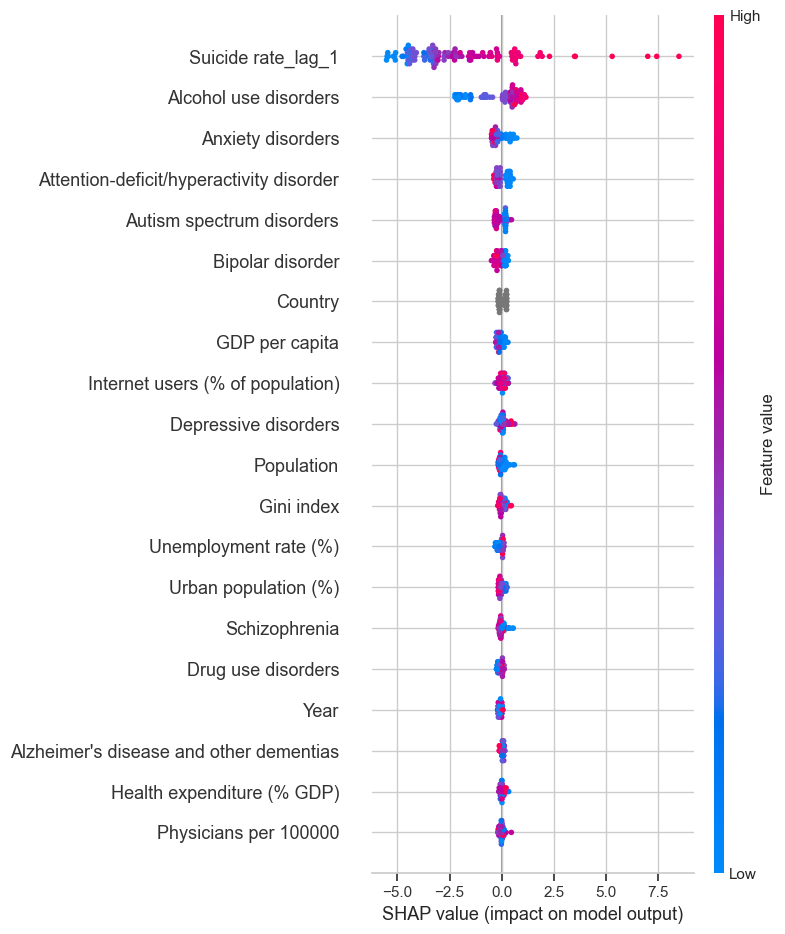

In [161]:
shap.summary_plot(shap_values, X_sample)

In [142]:
shap.initjs()

In [162]:
i = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_sample.iloc[i]
)

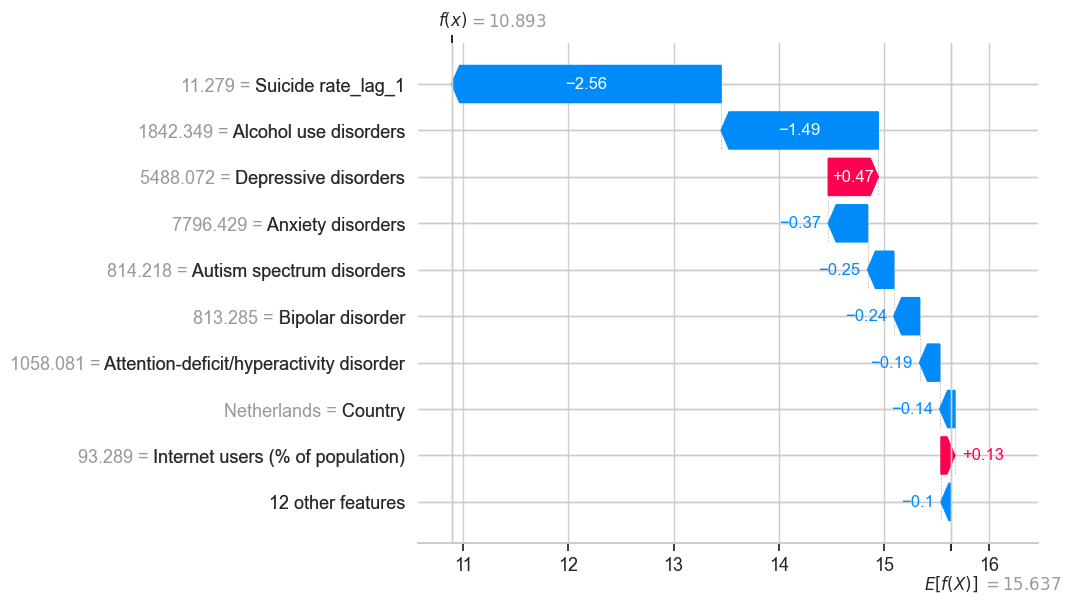

In [144]:
shap_values = explainer(X_sample)
shap.plots.waterfall(shap_values[i])

The SHAP analysis provides insight into how each feature contributes to the model's predictions. The model's baseline prediction is approximately 15.6, and each feature shifts this value positively or negatively for a given observation.

The results confirm that suicide_rate_lag_1 is by far the most influential feature, demonstrating a strong temporal dependency: higher suicide rates in the previous year generally lead to higher predicted rates in the current year. After introducing this lag feature, country is no longer among the most important predictors, indicating that temporal dynamics explain much of the variability previously attributed to geographical differences.

Among the socio-economic variables, alcohol use disorders have the strongest contribution, with higher values generally increasing the predicted suicide rate. Other mental health indicators and GDP exhibit only moderate effects, suggesting that their influence is either weaker or dependent on interactions with other variables rather than having a consistent linear impact.

Overall, the SHAP analysis shows that the model captures both non-linear relationships and feature interactions, explaining why it outperforms simpler linear approaches while maintaining good generalization performance.

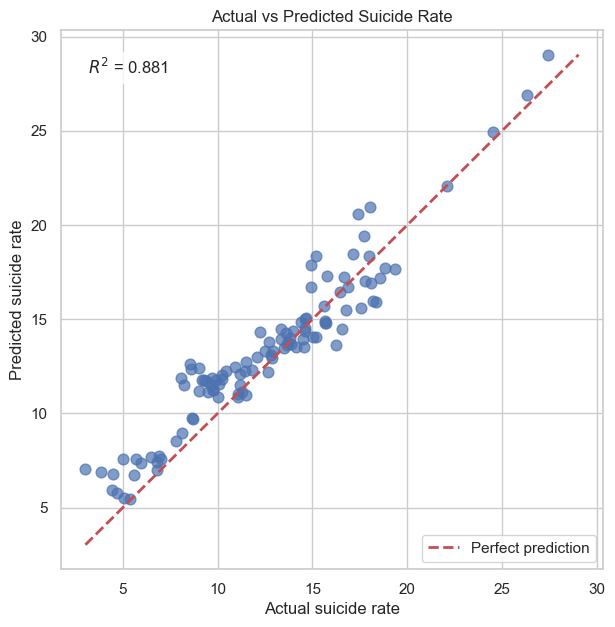

In [148]:

plt.figure(figsize=(7, 7))

# Scatter de valores reales frente a predichos
plt.scatter(
    y_val_lag,
    y_val_pred_lag,
    alpha=0.7,
    s=60
)

# Línea ideal (y = x)
lims = [
    min(y_val_lag.min(), y_val_pred_lag.min()),
    max(y_val_lag.max(), y_val_pred_lag.max())
]

plt.plot(
    lims,
    lims,
    "r--",
    linewidth=2,
    label="Perfect prediction"
)

r2 = r2_score(y_val_lag, y_val_pred_lag)

plt.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)


plt.xlabel("Actual suicide rate")
plt.ylabel("Predicted suicide rate")
plt.title("Actual vs Predicted Suicide Rate")
plt.legend()

plt.show()

In [165]:
results_val = X_val_lag.copy()

results_val["Actual"] = y_val_lag.values
results_val["Predicted"] = y_val_pred_lag

results_val["Residual"] = (
    results_val["Actual"] - results_val["Predicted"]
)

results_val["Absolute Error"] = (
    results_val["Residual"].abs()
)

results_val.head()

,Country,Year,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate_lag_1,Actual,Predicted,Residual,Absolute Error
17,Austria,2018,2958.464084,1415.265815,5027.956416,1064.819797,763.464481,717.642198,315.476090,2623.593928,859.084923,354.158132,51194.074984,4.933,10.515716,8840521.0,30.8,68.104679,87.479137,524.1,15.498706,15.703858,14.780369,0.923489,0.923489
18,Austria,2019,2952.114920,1426.372938,5085.749504,1058.937454,766.134026,716.809584,313.544202,2590.498011,837.423916,354.675998,49885.994736,4.560,10.625304,8879920.0,30.2,68.317604,87.752205,531.8,15.703858,14.583977,15.033163,-0.449186,0.449186
19,Austria,2020,2946.939352,1447.764115,6028.643630,1053.852381,768.407342,715.874031,312.319966,3180.104741,821.699112,354.920122,48716.409890,5.201,11.412930,8916864.0,29.8,68.541018,87.529428,534.4,14.583977,13.997377,14.372884,-0.375507,0.375507
20,Austria,2021,2942.834226,1457.075055,6153.200445,1050.525863,771.248962,715.339084,312.236619,3139.696364,809.233633,355.421821,53648.643798,6.459,12.185215,8955797.0,30.7,68.773602,92.529151,543.2,13.997377,14.513073,13.955844,0.557229,0.557229
38,Belgium,2018,2534.785504,1624.116653,5505.407910,856.049542,746.863966,694.587273,378.513213,3778.720818,868.397040,337.517047,47487.210039,5.941,10.993797,11427054.0,27.2,86.888345,88.647343,335.5,18.403234,18.576593,17.182375,1.394218,1.394218


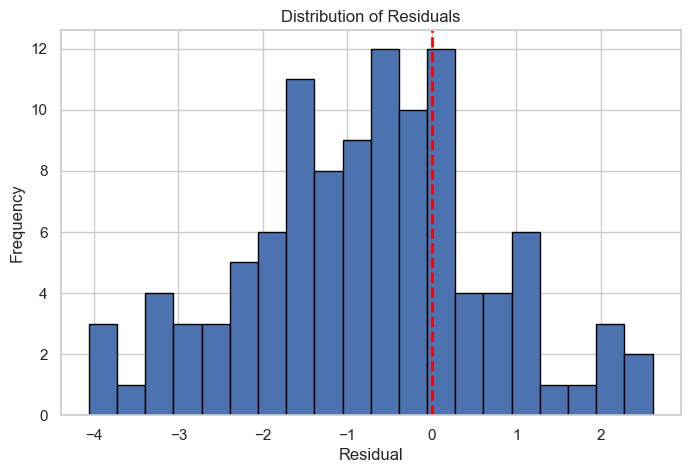

In [167]:
plt.figure(figsize=(8,5))

plt.hist(
    results_val["Residual"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

The residual analysis shows that the model tends to slightly overestimate the suicide rate. The distribution exhibits a longer left tail, indicating the presence of a small number of observations where the prediction error is substantially larger, suggesting the existence of outliers.

Despite these cases, most residuals remain centered around zero, indicating a generally good fit. The remaining errors likely reflect the inherent complexity and variability of suicide rates, making the phenomenon difficult to predict accurately across all observations.

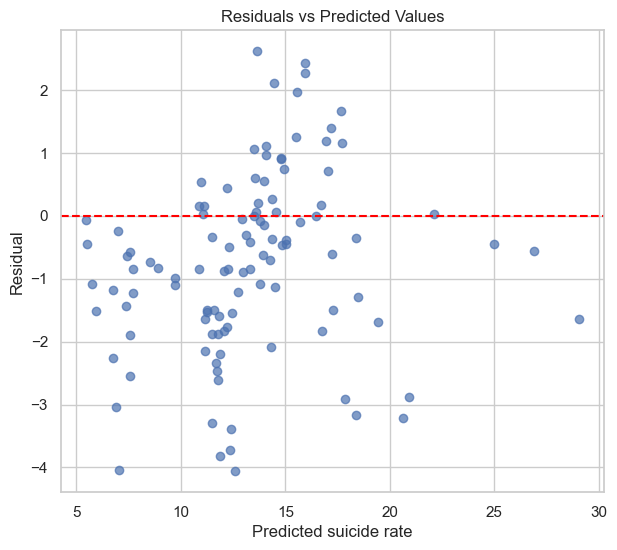

In [168]:
plt.figure(figsize=(7,6))

plt.scatter(
    results_val["Predicted"],
    results_val["Residual"],
    alpha=0.7
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted suicide rate")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

In [169]:
front_cols = ["Actual", "Predicted", "Residual", "Absolute Error"]

first_two = list(results_val.columns[:2])

rest = [c for c in results_val.columns if c not in first_two + front_cols]

cols = first_two + front_cols + rest

results_val = results_val[cols]

In [ ]:
results_val.sort_values(
    "Absolute Error",
    ascending=False
).head(10)

,Country,Year,Actual,Predicted,Residual,Absolute Error,Alcohol use disorders,Alzheimer's disease and other dementias,Anxiety disorders,Attention-deficit/hyperactivity disorder,Autism spectrum disorders,Bipolar disorder,Conduct disorder,Depressive disorders,Drug use disorders,Schizophrenia,GDP per capita,Unemployment rate (%),Health expenditure (% GDP),Population,Gini index,Urban population (%),Internet users (% of population),Physicians per 100000,Suicide rate_lag_1
293,Ireland,2021,8.546966,12.608029,-4.061063,4.061063,3201.147718,991.466772,8818.798597,1552.202447,930.973397,554.418345,446.830500,4046.540441,1168.049665,384.789976,103783.446284,6.357,6.441135,5110585.0,29.4,63.677423,93.506104,402.8,8.619221
104,Cyprus,2021,3.023157,7.056741,-4.033584,4.033584,1742.609099,892.820930,9299.513802,895.494396,783.903387,721.428494,353.496748,3445.841478,645.765303,355.030309,32937.839844,7.513,8.874451,1317309.0,31.3,66.671837,90.759516,335.5,3.864847
291,Ireland,2019,8.068050,11.882930,-3.814879,3.814879,3316.143140,968.574020,7136.007648,1557.433799,922.223417,550.951635,443.358329,3423.252332,1178.927487,382.249839,81827.668887,4.950,6.618606,4976456.0,30.3,63.273701,87.000055,331.7,9.286069
292,Ireland,2020,8.619221,12.345890,-3.726670,3.726670,3259.726393,977.829950,8536.734777,1555.403853,926.516003,552.666069,445.346433,3951.550525,1180.420159,383.285917,86514.070611,5.623,6.973233,5039747.0,29.2,63.471337,91.999891,345.8,8.068050
501,Slovakia,2019,9.018329,12.400915,-3.382586,3.382586,2641.213713,917.443806,4078.518555,428.536753,571.126408,560.603952,318.747113,2657.125845,584.248112,376.913493,19406.058968,5.761,6.911030,5454147.0,23.2,53.366656,82.853661,356.9,10.225459
377,Luxembourg,2021,8.224511,11.512575,-3.288064,3.288064,2537.816452,804.889868,6253.118888,881.854699,825.978430,717.219777,357.728406,5000.736327,1017.012810,355.659792,134965.815442,5.571,5.608061,640064.0,32.7,94.586174,98.660863,298.4,9.686833
521,Slovenia,2018,17.399156,20.607700,-3.208544,3.208544,3664.925119,1285.242125,5422.188876,402.860478,598.206081,561.793723,299.584412,2862.694518,709.909501,382.178013,25888.048107,5.108,8.352286,2073894.0,24.6,55.191343,79.749977,318.5,20.427216
335,Latvia,2021,15.206412,18.378692,-3.172280,3.172280,2999.743696,1414.429636,4473.553256,406.950476,662.403862,559.811509,329.666210,3914.961927,789.085208,280.651577,20261.888779,7.513,9.410507,1884490.0,34.3,68.180879,91.179650,335.6,18.006217
103,Cyprus,2020,3.864847,6.901244,-3.036397,3.036397,1757.742990,874.057940,9040.607188,904.315970,780.645451,721.817070,354.338143,3384.087842,635.828261,352.817694,28130.341797,7.755,8.647964,1302247.0,31.7,66.718044,90.801946,319.7,4.499632
167,Estonia,2021,14.938198,17.855369,-2.917172,2.917172,2396.342677,1370.662401,3820.687639,417.664586,682.039102,559.661385,340.204876,3885.086036,1551.469318,290.656813,27951.165928,6.178,7.475911,1330932.0,31.8,70.177727,90.979702,343.0,17.539419


In [155]:

country_error = (
    results_val
    .groupby("Country")["Absolute Error"]
    .mean()
    .sort_values(ascending=False)
)

country_error.head(10)

Country
Ireland       3.516156
Cyprus        2.627376
Slovakia      2.356063
Slovenia      1.931037
Latvia        1.922312
Romania       1.893308
Luxembourg    1.825739
Malta         1.779136
France        1.701354
Estonia       1.619445
Name: Absolute Error, dtype: float64

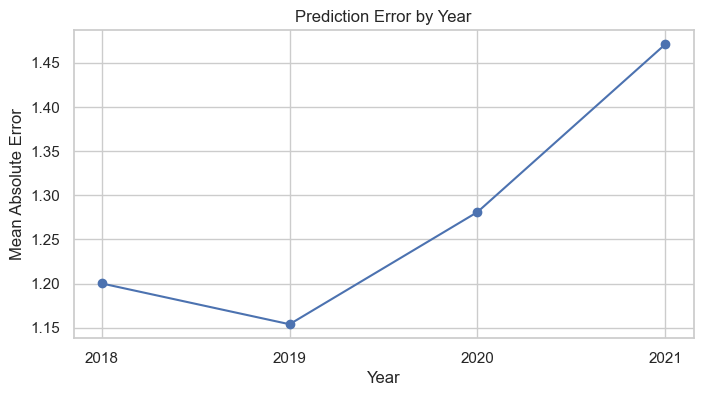

In [175]:
year_error = (
    results_val
    .groupby("Year")["Absolute Error"]
    .mean()
)

plt.figure(figsize=(8,4))

plt.plot(
    year_error.index,
    year_error.values,
    marker="o"
)

plt.xticks(year_error.index.astype(int))

plt.xlabel("Year")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Year")

plt.grid(True)

plt.show()

Covid??